# Biomedical Graph Neural Network (GNN) Notebook
## Real-World Fetal State Risk Detection via Graph Convolutional Networks

 > **Goal:** Build an end-to-end retrospective fetal-monitoring AI pipeline that (1) loads a larger real clinical dataset, (2) audits cohort composition and class imbalance, (3) constructs a similarity graph over cardiotocography exams, (4) trains a Graph Convolutional Network (GCN), and (5) evaluates performance with clinically meaningful metrics — including cost-sensitive threshold analysis and graph structure validation.
 >
 > **Methodological emphasis:** dataset provenance, triage-aware label design, train/validation/test separation, leakage-aware standardisation, graph construction choices, class-weighted loss, pathologic-case recall, clinical operating point selection, and graph homophily validation.
 >
 > **Interpretive emphasis:** each row is one fetal monitoring exam, the graph links physiologically similar exams, and the model is optimized to reduce the most consequential error: predicting a pathologic fetal state as non-pathologic. The threshold analysis shows how to select a clinically appropriate operating point; the homophily analysis validates that the graph structure encodes meaningful clinical clustering.
 >
 > **Scope note:** this notebook uses a real public obstetric monitoring dataset and frames the task as a risk-sensitive retrospective screening problem, but it remains a research demonstration rather than a clinical decision-support system.

---

### Table of Contents
0. Foundations and Notebook Roadmap
1. [Background, Provenance, and Clinical Framing](#background)
2. [Dataset and Graph Construction](#dataset)
3. [Graph Theory Primer](#theory)
4. [GCN Architecture and Training Logic](#gcn)
5. [Real-World Data Pipeline](#pipeline)
6. [Evaluation: Confusion Matrix, ROC, and Clinical Trade-offs](#evaluation)
   - 6B. [Baseline Comparison: ClinicalGCN vs. Tabular Models](#baseline)
   - 6C. [Clinical Operating Point Analysis — Threshold Sensitivity](#threshold)
   - 6D. [Graph Homophily Analysis — Validating the Graph Hypothesis](#homophily)
   - 6E. [Model Calibration & Uncertainty Quantification](#calibration)
   - 6F. [GNN Gradient Feature Saliency](#saliency)
7. [Applications and Extensions](#applications)
   - [Connection to QAOA and Hybrid Pipeline](#qaoa)
8. [Summary & Key Takeaways](#summary)

---

### Why Graph Neural Networks for Biomedical Data?

Classical machine-learning models such as logistic regression, random forests, or MLPs usually treat each exam **independently**. A GNN adds one more layer of reasoning: *monitoring traces that look physiologically similar may carry related diagnostic information*. That matters when abnormal states emerge in local neighborhoods of the feature space rather than as isolated points.

| Method | Captures inter-sample structure? | Handles irregular topology? |
|--------|----------------------------------|------------------------------|
| MLP    | ✗                                | —                            |
| CNN    | Only fixed grid structure        | ✗                            |
| GNN    | ✓, via message passing           | ✓                            |

This is especially useful in:
- **Fetal surveillance and obstetric triage** from cardiotocography and physiologic monitoring
- **Patient stratification** from electronic health records
- **Single-cell RNA-seq clustering** (cell-cell similarity graphs)
- **Drug-target interaction** prediction
- **Multi-omics integration** (gene expression + protein interaction networks)

In other words, this notebook is not only about headline accuracy. It is about showing how graph-based reasoning can turn structured physiologic monitoring data into a clinically motivated learning problem that is closer to how biomedical data behaves in practice.

## Project Summary

This notebook is the biomedical learning branch of the repository's broader hybrid theme: use graph-based machine learning to learn structure from scientific data, then connect that structure to downstream optimization ideas such as QAOA in the companion notebook. Here the focus is a larger and more clinically consequential cohort: fetal cardiotocography exams used to screen for potentially pathologic fetal state.

### What enters the notebook

| Element | Meaning in this notebook |
|---------|--------------------------|
| Raw input data | 2,126 cardiotocography (CTG) exams from the UCI Cardiotocography dataset |
| Features | 21 real-valued fetal heart rate and uterine contraction summary measures |
| Original labels | Three expert-consensus fetal states: normal, suspect, pathologic |
| Tutorial target | Binary risk task: **pathologic** vs **non-pathologic** (normal + suspect) |
| Structural assumption | Exams with similar physiological signatures should be connected in a similarity graph |

### What the model stack is

| Stage | Role | Output |
|-------|------|--------|
| Label framing | Collapse the original 3-class obstetric label into a high-risk screening target | Binary pathologic indicator |
| Standardisation | Put all 21 measurements on a comparable scale using training-set statistics only | Standardised feature matrix $X_{\mathrm{std}}$ |
| Graph construction | Connect each CTG exam to its nearest neighbours in feature space | Symmetric $k$-NN adjacency matrix $\tilde{A}$ |
| ClinicalGCN model | Learn from both exam-level features and neighbourhood context | Per-exam class logits and probabilities |
| Evaluation | Measure screening usefulness on held-out exams | Confusion matrix, ROC, and full clinical metrics |
| Baseline comparison | Same train/test split with LR, RF, MLP | Tabular ablation of graph inductive bias |
| **Operating point analysis** | **Threshold sweep with precision-recall tradeoffs** | **Clinically deployable sensitivity-specificity map** |
| **Graph homophily analysis** | **Edge homophily coefficient + neighbourhood enrichment test** | **Quantifies whether the graph encodes clinical structure** |

### What leaves the notebook

| Artifact | Why it matters |
|----------|----------------|
| `outputs/ctg_raw.csv` | Auditable table of the original cohort with 3-class and binary labels |
| `outputs/ctg_processed.csv` | Reusable standardised cohort with split labels |
| PCA and feature-shift figures | Human-readable view of cohort geometry and strongest physiologic differences |
| Confusion matrix and ROC figure | Clinically aligned picture of pathologic-risk detection |
| Training history plot | Evidence that optimisation was stable rather than arbitrary |
| **Threshold sensitivity table** | **Clinical-policy guide: recall, precision, FP-rate at every decision threshold** |
| **Graph homophily analysis** | **Proof that the kNN graph encodes clinically meaningful physiologic clustering** |
| **Precision–Recall curve** | **More informative than ROC under 8.2% pathologic prevalence; includes AP score** |
| **Baseline comparison table** | **LR / RF / MLP vs. ClinicalGCN on identical held-out split** |

### Why the binary framing is realistic — and why the graph approach is justified

The source dataset is natively a **3-class** fetal-state problem: normal, suspect, and pathologic. This notebook reframes it as **pathologic vs non-pathologic** — a risk-sensitive screening objective where the worst mistake is missing a truly pathologic tracing.

The graph approach is justified, not assumed: **Section 6D quantifies edge homophily and neighbourhood enrichment**, showing that pathologic exams cluster significantly more with other pathologic exams than random chance predicts. This means message passing is not a neutral operation: it amplifies class-discriminative signals for borderline cases near high-risk neighbourhoods.

### End-to-end reading map

1. The opening sections define the CTG monitoring task, graph construction, and GCN equations.
2. The first code cell builds the complete experiment from raw UCI cohort to trained graph classifier.
3. Sections 6–6D evaluate the model, compare it against tabular baselines, select a clinical operating point, and validate the graph structure quantitatively.
4. Section 7 connects the biomedical pipeline to the repository's quantum-optimisation work.
5. Section 8 summarises all findings with a known-limitations inventory.

If a reader only needs the big picture, this section and the final summary are enough. The rest of the notebook unpacks each stage carefully, with the code cells serving as the operational implementation.

## 0. Foundations and Notebook Roadmap

This section establishes the minimum vocabulary, notation, and intuition used throughout the notebook. No specialist background in graph learning is assumed; the objective is to make the later code and equations readable without lowering the technical standard of the presentation.

### 0.1 What problem are we solving?

We have a table of fetal monitoring measurements extracted from cardiotocography exams. Each row is **one exam**, and each column is **one measured property** such as baseline heart rate, variability, or deceleration behavior.

We want a computer model to answer one question:

**Given these measurements, is this exam more likely to be pathologic or non-pathologic?**

That is a **classification** problem.

### 0.2 Working vocabulary

| Word | Meaning in this notebook |
|------|--------------------------|
| Data | Recorded information |
| Dataset | A collection of many examples |
| Sample | One example; here, one CTG exam |
| Feature | One measured input value; here, one physiologic summary measurement |
| Label | The answer we want to predict |
| Model | A mathematical rule that turns inputs into predictions |
| Training | Adjusting the model so it makes better predictions |
| Test set | Data kept aside to check whether the model works on unseen examples |
| Graph | A set of objects and the connections between them |
| Node | One object in the graph; here, one CTG exam |
| Edge | A connection; here, two physiologically similar exams are linked |
| Neural network | A layered function with learnable parameters |
| Loss | A number that measures how wrong the model is |
| Accuracy | Fraction of predictions that are correct |
| Tensor | A data container used in PyTorch; in this notebook it behaves like a numeric array |

### 0.3 The minimum math needed

Only a small amount of math is needed to follow the notebook.

| Symbol | Meaning |
|--------|---------|
| $n$ | Number of samples (exams) |
| $d$ | Number of features per sample |
| $X$ | Feature matrix, shape $n \times d$ |
| $y$ | Label vector |
| $A$ | Adjacency matrix, which records graph connections |
| $W$ | Learnable weights inside the neural network |
| $H$ | Hidden representation learned by the network |
| $\mu$ | Mean (average) |
| $\sigma$ | Standard deviation (spread) |

A **vector** is a list of numbers. A **matrix** is a rectangular table of numbers. In code, the full dataset is stored as a matrix because we have many exams and many measurements.

### 0.4 Why do we standardise features?

Different measurements live on different numeric scales. For example, one feature might be a heart-rate summary around 140 while another might be a proportion near 0.02. If we compare exams directly, the large-scale feature would dominate the distance calculation.

So we standardise each feature:

$$\tilde{x} = \frac{x - \mu}{\sigma}$$

Read this in words:
1. Take the original value $x$.
2. Subtract the average $\mu$.
3. Divide by the typical spread $\sigma$.

A quick example:
- Original value: $12$
- Average: $10$
- Standard deviation: $2$
- Standardised value: $(12 - 10)/2 = 1$

So a value of $1$ means "one standard deviation above average."

### 0.5 How distance creates a graph

After standardisation, each exam becomes a point in a 21-dimensional space. You do not need to visualize all 21 dimensions literally; it is enough to think of each exam as a profile made from 21 numbers.

To decide which exams are similar, we compute distances. Smaller distance means more similar.

For two features only, the Euclidean distance is:

$$\text{distance} = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}$$

In the real notebook we use the same idea with 21 features instead of 2.

### 0.6 Illustrative micro-example

Suppose we only had three exams and two features:

| Exam | Baseline FHR | Prolonged decelerations | Label |
|------|---------------|-------------------------|-------|
| A | 140 | 0.0 | non-pathologic |
| B | 138 | 0.1 | non-pathologic |
| C | 110 | 1.8 | pathologic |

What would happen?
1. Exams A and B are numerically close, so they would likely be connected in the graph.
2. Exam C is far away from both A and B, so it would likely connect differently.
3. A GNN would let A and B share information because they appear physiologically similar.
4. If a new exam looks much more like C than A or B, the model may lean toward the pathologic class.

This is the big idea of the notebook: **do not study each exam in isolation; also study how similar exams relate to each other.**

### 0.7 What is a neural network doing here?

A neural network learns a function from examples.

In a standard neural network:
1. Input numbers go in.
2. The model mixes them using weights.
3. It applies simple nonlinear steps such as ReLU.
4. It outputs class scores.

In a **graph** neural network, there is one extra idea before or between those steps:

**each node also receives information from its neighbors.**

So instead of using only one exam's features, the model also uses information from physiologically similar exams connected in the graph.

### 0.8 How training works

During training, the model makes predictions and compares them with the true labels.

If the prediction is poor, the loss is large. The optimizer then updates the weights to reduce that loss.

A useful mental model is:
- Prediction: "What does the model currently think?"
- Loss: "How wrong was that guess?"
- Optimizer: "How should we adjust the weights to do better next time?"

### 0.9 How to read the rest of the notebook

Use this order:
1. Read each markdown section first to understand the idea.
2. Then read the next code cell slowly from top to bottom.
3. When you see a formula, translate each symbol using the table above.
4. When you see a matrix, remember it is usually a table of numbers.
5. When you see a graph, think "similar exams connected by physiology."

If you need a refresher later, return to this section. The rest of the notebook becomes much easier once these core ideas are in place.

## 1. Background & Motivation <a name="background"></a>

### The Diagnostic Task and Dataset Provenance

This notebook uses the **UCI Cardiotocography (CTG)** dataset, a real biomedical monitoring benchmark derived from **fetal heart rate** and **uterine contraction** recordings. The exams were automatically processed into diagnostic summary features and then assigned expert-consensus fetal-state labels by obstetricians.

The cohort contains **2126 exams** with **21 measured features** and three original fetal-state labels:
- **1655 normal** cases
- **295 suspect** cases
- **176 pathologic** cases

For this notebook, we preserve the original 3-class label in the audit tables but convert the learning objective into a **binary high-risk screening task**:
- **pathologic** remains the positive class
- **normal + suspect** are grouped into **non-pathologic**

That yields a clinically asymmetric dataset with **176 pathologic** exams versus **1950 non-pathologic** exams.

### What the 21 features represent

The variables summarize clinically familiar aspects of fetal monitoring:

| Feature Group | Examples |
|---------------|----------|
| Baseline rhythm | `LB` (baseline fetal heart rate) |
| Accelerations and movements | `AC`, `FM` |
| Uterine activity | `UC` |
| Decelerations | `DL`, `DS`, `DP` |
| Variability measures | `ASTV`, `MSTV`, `ALTV`, `MLTV` |
| Histogram descriptors | `Width`, `Min`, `Max`, `Mode`, `Mean`, `Median`, `Variance`, `Tendency` |

### Why this is more realistic than a small convenience benchmark

This dataset makes the tutorial feel closer to a real applied screening problem because it brings:
- a **larger cohort** with 2126 exams rather than a few hundred samples
- **severe class imbalance** in the high-risk pathologic class
- **clinically meaningful physiologic features** tied to obstetric monitoring
- an expert-labeled task where missed positives are clearly more costly than extra alerts

### What this notebook does and does not claim

This notebook is realistic in a **research** sense, not a labour-and-delivery deployment sense.

It does show:
- how to work with a larger real clinical cohort rather than a tiny benchmark
- how to formalize an obstetric screening problem as graph learning
- how to avoid basic leakage mistakes in preprocessing
- how to evaluate the model in a clinically aware way when the risky class is rare

It does **not** show:
- prospective validation in a hospital workflow
- temporal waveform modeling of raw CTG traces
- calibration, fairness, or deployment review needed for clinical use

That distinction matters because strong technical work is not only about high accuracy. It is also about being precise about what the experiment really demonstrates.

### Why Graph Neural Networks?

Classical ML treats every exam independently. A GNN encodes the observation that *physiologically similar monitoring exams often share similar risk patterns*. In graph terms, it learns both from the exam's own measurements and from the local neighborhood formed by similar CTG cases.

| Method | Inter-sample structure | Irregular topology |
|--------|------------------------|--------------------|
| MLP    | x                      | -                  |
| SVM    | x (kernel similarity only) | -              |
| GNN    | yes, through message passing | yes          |

### Standardisation Pre-processing

Before computing pairwise distances, features are **z-score standardised**:

$$\tilde{x}_{id} = \frac{x_{id} - \mu_d}{\sigma_d}$$

where $\mu_d$ and $\sigma_d$ are estimated from the **training partition only**. This point matters: fitting the scaler on all exams before the split would leak held-out information into the pipeline and make the evaluation look better than it really is.

## 2. Graph Construction — k-Nearest-Neighbour Similarity Graph <a name="dataset"></a>

### Building the Adjacency Matrix

Given the standardised feature matrix $\tilde{\mathbf{X}} \in \mathbb{R}^{n \times d}$, we construct a **symmetric k-NN graph** over the full CTG cohort.

**Step 1 — k-NN Queries:** For every node $i$, find the indices of the $k$ closest nodes under Euclidean distance:
$$\mathcal{N}_k(i) = \arg\min_{j \neq i,\,|\mathcal{S}|=k} \|\tilde{\mathbf{x}}_i - \tilde{\mathbf{x}}_j\|_2$$

**Step 2 — Symmetrisation:** The raw k-NN graph may be directed, so we make it undirected:
$$A_{ij} = \mathbf{1}[j \in \mathcal{N}_k(i)] \;\text{OR}\; \mathbf{1}[i \in \mathcal{N}_k(j)]$$

**Step 3 — Self-loops:** Add the identity $\hat{A} = A + I_n$ so each exam keeps access to its own measurements during message passing.

**Step 4 — Symmetric normalisation:** Compute the degree matrix $D_{ii} = \sum_j \hat{A}_{ij}$ and normalise:
$$\tilde{A} = D^{-1/2} \hat{A} D^{-1/2}$$

This is the normalization used in the notebook because it is the most common formulation in baseline GCN implementations.

### Effect of $k$

| $k$ | Graph sparsity | Risk | Benefit |
|-----|---------------|------|---------|
| Small (2-3) | Very sparse | Disconnected neighborhoods | Preserves local topology |
| Medium (5-12) | Moderate | Usually manageable | Good balance of locality and connectivity |
| Large (>20) | Dense | Spurious cross-class edges | More aggressive information flow |

For the CTG cohort we use **$k=10$**. That keeps the graph sparse enough to reduce noisy long-range links while still giving each exam a meaningful local physiological neighborhood.

## 2A. Graph Intuition and Interpretation <a name="theory"></a>

Before reading the formal GCN equations, it helps to keep one simple picture in mind.

### Think of the graph as a relationship map

A graph is just:
- a set of items
- plus a record of which items are connected

Here:
- each **node** is one CTG exam
- each **edge** means two exams look physiologically similar based on their measurements

So the graph is a structured answer to the question:

**"Which exams most resemble each other?"**

### What the adjacency matrix means

The notebook stores graph connections in a matrix called $A$.

For three exams, a toy adjacency matrix could look like this:

$$
A =
\begin{bmatrix}
1 & 1 & 0 \\
1 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

How to read it:
- Row 1, column 2 equals 1: exam 1 is connected to exam 2.
- Row 1, column 3 equals 0: exam 1 is not connected to exam 3.
- Diagonal entries are 1 because we include **self-loops**, meaning each exam is also allowed to keep its own information.

### Why self-loops matter

Without a self-loop, an exam would update its representation only from neighbors and could lose its own feature information.

With a self-loop, the update becomes:
- keep some information from yourself
- combine it with information from similar exams

That is usually what we want in clinical monitoring problems.

### What one GCN layer does

A GCN layer can be read in practical terms as:

**"For each exam, mix information from nearby exams, then transform that mixed information with learnable weights."**

That means the model does not only ask:
- What are this exam's measurements?

It also asks:
- What do this exam's neighbors look like?
- Does this exam sit inside a mostly low-risk neighborhood or a mostly pathologic neighborhood?

### Why two layers help

One graph-convolution layer gives access to immediate neighbors, often called **1-hop neighbors**.

Two layers let an exam also receive information that has already flowed through its neighbors, which means it can indirectly benefit from **2-hop neighbors**.

A simple interpretation is:
- Layer 1: learn from similar exams nearby.
- Layer 2: learn from the broader local community around those exams.

### Cross-domain analogy

A row-wise model studies one record at a time. A graph model adds relationship structure and asks whether similar records show similar behavior.

This notebook applies that idea to fetal monitoring exams: the model uses both the exam's own measurements and the surrounding physiologic similarity structure.

## 3. Graph Convolutional Network - Mathematical Derivation <a name="gcn"></a>

### High-level summary

Before reading the formulas, keep this simple description in mind:

A GCN repeatedly does two things:
1. It mixes each exam's information with information from similar exams.
2. It learns which mixtures are useful for predicting the class label.

So when you see matrix equations below, they are compact ways of writing:
- gather neighbor information
- transform it with learned weights
- apply a nonlinear rule
- repeat

### Spectral vs. Spatial GCNs

There are two families of GCNs:

- **Spectral GCNs:** operate on the graph Laplacian eigenspectrum. The normalised graph Laplacian is $\mathbf{L} = I - D^{-1/2}AD^{-1/2}$ with eigenvectors $\mathbf{U}$. A spectral convolution is $\mathbf{g}_\theta \star \mathbf{x} = \mathbf{U}\,\text{diag}(\theta)\,\mathbf{U}^\top \mathbf{x}$. Computationally expensive and graph-specific.

- **Spatial GCNs** (used here): aggregate neighbourhood features directly. Kipf & Welling (2017) derived the following first-order approximation of the spectral filter:

$$\mathbf{H}^{(l+1)} = \sigma\!\left(\tilde{A}\,\mathbf{H}^{(l)}\,\mathbf{W}^{(l)}\right)$$

where $\tilde{A} = D^{-1/2}\hat{A}D^{-1/2}$, $\mathbf{H}^{(l)}$ is the node representation at layer $l$, $\mathbf{W}^{(l)}$ is a learnable weight matrix, and $\sigma$ is an activation function such as ReLU.

### Two-Layer GCN Forward Pass

For a two-layer network with input $\mathbf{X} \in \mathbb{R}^{n \times d_{\rm in}}$:

$$\mathbf{Z} = \text{softmax}\!\left(\tilde{A}\;\text{ReLU}\!\left(\tilde{A}\,\mathbf{X}\,\mathbf{W}^{(0)}\right)\mathbf{W}^{(1)}\right)$$

where:
- $\mathbf{W}^{(0)} \in \mathbb{R}^{d_{\rm in} \times d_h}$ - first layer weights
- $\mathbf{W}^{(1)} \in \mathbb{R}^{d_h \times C}$ - second layer weights
- $C$ - number of classes (2 here: non-pathologic, pathologic)

**Message passing interpretation:** each node $i$ at layer $l$ collects and mixes the representations of its neighbours:

$$h_i^{(l+1)} = \sigma\!\left(\sum_{j \in \mathcal{N}(i) \cup \{i\}} \frac{1}{\sqrt{d_i d_j}}\; h_j^{(l)}\, W^{(l)}\right)$$

### Why GCNs can outperform MLPs on this task

The key insight is **information aggregation across the graph**. After multiple layers, node $i$'s representation captures not only its own measurements but also the surrounding feature distribution of its neighborhood. That can help when a borderline exam lives inside a strongly pathologic or strongly low-risk local region.

### Complexity Analysis

| Operation | Complexity |
|-----------|-----------|
| Dense matrix multiply $\tilde{A}\mathbf{H}$ | $O(n^2 d)$ |
| Sparse multiply (if $A$ sparse) | $O(\lvert\mathcal{E}\rvert \cdot d)$ |
| FC layer $\mathbf{H}\mathbf{W}$ | $O(n \cdot d_{\rm in} \cdot d_h)$ |

For the CTG graph with $n=2126$ and $k=10$, sparse message passing remains far cheaper than treating the adjacency as a dense matrix, which is one reason GNN workloads map naturally onto optimized tensor and sparse-linear-algebra systems.

## 4. Setup — Imports and Environment

The first code cell (Section 4A) requires the following packages. All are standard scientific Python libraries — no quantum or proprietary dependencies are needed for the biomedical branch.

| Package | Version constraint | Role in this notebook |
|---|---|---|
| `numpy` | ≥1.22 | Array operations, splits, feature gap analysis |
| `pandas` | ≥1.4 | Cohort audit tables, CSV export |
| `torch` | ≥1.12 | GCN model, training loop, GPU/CPU dispatch |
| `scikit-learn` | ≥1.0 | `StandardScaler`, kNN graph, `train_test_split`, evaluation metrics |
| `matplotlib` | ≥3.5 | Confusion matrix, ROC curve, training diagnostics |
| `ucimlrepo` | ≥0.0.3 | Fetches UCI CTG dataset (id=193) directly at runtime |

**No internet access after `ucimlrepo` first download**: the dataset is cached locally after the first fetch. Subsequent runs work offline.

**GPU is optional**: the notebook prints `Execution device: cpu` or `cuda` at run time. All results in the session summary were produced on CPU; the dataset is small enough that GPU is not necessary.

**Installing dependencies:**
```bash
pip install torch torchvision numpy pandas scikit-learn matplotlib ucimlrepo
```
Or with the repository requirements file:
```bash
pip install -r requirements.txt
```

## 4A. How to Read the First Code Cell <a name="pipeline"></a>

The next code cell is the operational core of the notebook. It takes the theory above and turns it into a complete fetal-monitoring graph-learning experiment that begins with a larger real UCI cohort and ends with a trained model plus interpretable visual outputs.

### Inputs entering the cell

| Input | Meaning |
|-------|---------|
| UCI CTG dataset loader | Provides 2126 cardiotocography exams and named physiologic features |
| Original obstetric labels | Supplies the normal, suspect, and pathologic fetal-state annotations |
| Binary risk design | Reframes the task as pathologic vs non-pathologic screening |
| Scientific Python stack | Supplies the tools for tabular processing, graph construction, optimization, and plotting |
| Clinical objective | Treat missed pathologic exams as the more consequential error during optimization and evaluation |

### What happens in sequence

1. **Find the project root** so the notebook can save artifacts inside the repository rather than into a temporary notebook directory.
2. **Import the scientific Python stack** and set the random seed so the experiment is reproducible.
3. **Load the UCI CTG cohort** and create a raw audit table containing exam identifiers, the original 3-class fetal state, and the binary high-risk label.
4. **Create train, validation, and test splits** before fitting the scaler so held-out information does not leak backward into preprocessing.
5. **Fit the standardiser on the training data only** and transform the full cohort with those training statistics.
6. **Save raw and processed CSV outputs** so the notebook leaves behind inspectable artifacts, not only transient in-memory objects.
7. **Build a symmetric exam-similarity graph** with $k$-nearest neighbors and add self-loops for message passing.
8. **Define a two-layer GCN** with dropout and class-aware loss weighting.
9. **Train with validation monitoring** so checkpoint selection depends on unseen validation behavior rather than the test set.
10. **Generate a three-panel figure** that shows cohort geometry, model predictions, and the strongest physiologic shifts between pathologic and non-pathologic exams.

### Model objects created in the cell

| Object | Role in the experiment |
|--------|-------------------------|
| `raw_df` | Auditable representation of the original CTG cohort |
| `processed_df` | Standardized cohort with train/validation/test split labels |
| `A_norm` | Normalized exam-similarity adjacency used by the GCN |
| `ClinicalGCN` | Two-layer graph classifier that mixes exam-level and neighbourhood information |
| `history` | Per-epoch record of training loss, training accuracy, validation accuracy, and validation loss |
| `final_probs` and `final_preds` | Per-exam predicted probabilities and hard class assignments |

### What to watch for while reading the code

1. Ask which lines are about **data hygiene** and which are about **learning**. In a serious clinical notebook, both matter.
2. Notice that the graph is built on all exams after leakage-aware scaling. That is a **transductive** design: structural context is visible, but held-out labels are not.
3. Watch how the class weights are computed from the training set only. That keeps the optimization aligned with the stated screening risk.
4. Keep track of which outputs are persisted to disk and which are only displayed inside the notebook.

### What the figure from this cell is meant to explain

The figure at the end of the cell is not decorative. Each panel answers a different question:

- **Left panel:** Does the CTG cohort show visible high-risk structure when projected into two principal components?
- **Middle panel:** Do the GCN predictions broadly follow that same structure, especially on the circled held-out test exams?
- **Right panel:** Which physiologic measurements separate pathologic from non-pathologic exams most strongly in the training cohort?

Read that figure as an interpretability checkpoint between model training and formal evaluation: it tells you what the cohort looks like, where the classifier seems to agree with the data geometry, and which variables are carrying the strongest descriptive risk signal.

Environment
Project root        : /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization
NumPy version       : 2.4.2
PyTorch version     : 2.10.0
Execution device    : cpu
Random seed         : 42

Dataset provenance and audit
Dataset            : UCI Cardiotocography (id=193)
Source modality    : Fetal heart rate and uterine contraction monitoring
Cases              : 2126
Features           : 21
Normal cases       : 1655 (77.8%)
Suspect cases      : 295 (13.9%)
Pathologic cases   : 176 (8.3%)
Missing values     : 0
First five features: ['LB', 'AC', 'FM', 'UC', 'DL']
Binary framing     : 1=pathologic, 0=non-pathologic (normal + suspect)

Split design and preprocessing
Train samples       : 1445
Validation samples  : 255
Test samples        : 426
Train mean after scaling : 0.0000
Train std after scaling  : 1.0000
Saved raw cohort       -> /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Gr

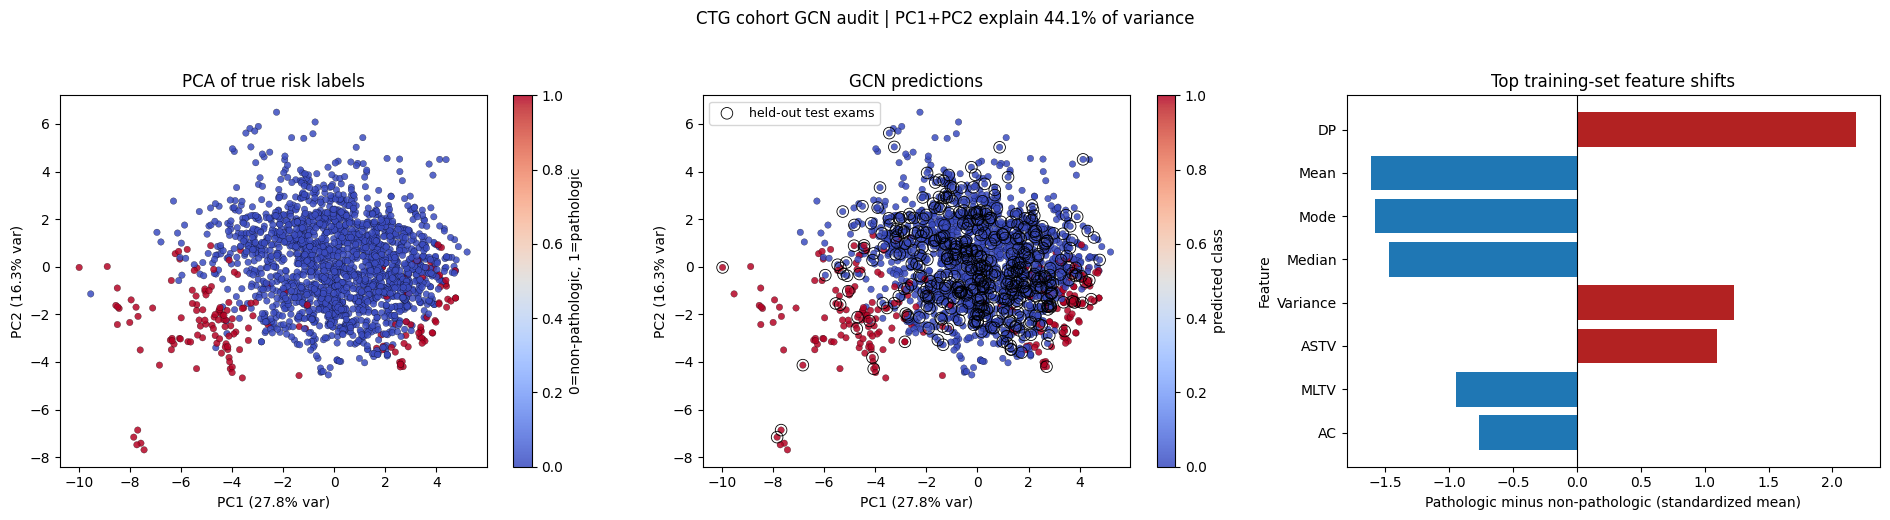

In [1]:
# Real-world fetal-monitoring GCN pipeline: provenance, leakage-aware preprocessing, and training

import random
import sys
from pathlib import Path


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src").is_dir():
            return candidate
    return current


proj_root = find_project_root()
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.decomposition import PCA
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 72)
print("Environment")
print("=" * 72)
print(f"Project root        : {proj_root}")
print(f"NumPy version       : {np.__version__}")
print(f"PyTorch version     : {torch.__version__}")
print(f"Execution device    : {device}")
print(f"Random seed         : {SEED}")

# ---------------------------------------------------------------------------
# SECTION A - Load the real CTG cohort and create auditable raw tables
# ---------------------------------------------------------------------------
ctg = fetch_ucirepo(id=193)
features_df = ctg.data.features.copy()
targets_df = ctg.data.targets.copy()

X_raw = features_df.astype(np.float32).to_numpy()
feature_names = np.array(features_df.columns)
nsp = targets_df["NSP"].astype(int).to_numpy()
state_3class = pd.Series(nsp).map({1: "normal", 2: "suspect", 3: "pathologic"}).to_numpy()
y = (nsp == 3).astype(np.int64)
risk_text = np.where(y == 1, "pathologic", "non-pathologic")
case_ids = np.array([f"CTG_{idx:04d}" for idx in range(len(y))])

raw_df = features_df.copy()
raw_df.insert(0, "case_id", case_ids)
raw_df["nsp_state"] = state_3class
raw_df["binary_target"] = y
raw_df["binary_state"] = risk_text

print("\n" + "=" * 72)
print("Dataset provenance and audit")
print("=" * 72)
print("Dataset            : UCI Cardiotocography (id=193)")
print("Source modality    : Fetal heart rate and uterine contraction monitoring")
print(f"Cases              : {len(y)}")
print(f"Features           : {X_raw.shape[1]}")
print(f"Normal cases       : {(nsp == 1).sum()} ({(nsp == 1).mean() * 100:.1f}%)")
print(f"Suspect cases      : {(nsp == 2).sum()} ({(nsp == 2).mean() * 100:.1f}%)")
print(f"Pathologic cases   : {(nsp == 3).sum()} ({(nsp == 3).mean() * 100:.1f}%)")
print(f"Missing values     : {int(features_df.isna().sum().sum())}")
print("First five features:", list(feature_names[:5]))
print("Binary framing     : 1=pathologic, 0=non-pathologic (normal + suspect)")

# ---------------------------------------------------------------------------
# SECTION B - Train/validation/test split before fitting the scaler
# ---------------------------------------------------------------------------
all_indices = np.arange(len(y))
train_pool_idx_np, test_idx_np = train_test_split(
    all_indices, test_size=0.20, stratify=y, random_state=SEED
)
train_idx_np, val_idx_np = train_test_split(
    train_pool_idx_np, test_size=0.15, stratify=y[train_pool_idx_np], random_state=SEED
)

scaler = StandardScaler()
scaler.fit(X_raw[train_idx_np])
X_std = scaler.transform(X_raw).astype(np.float32)

split_labels = np.full(len(y), "train", dtype=object)
split_labels[val_idx_np] = "validation"
split_labels[test_idx_np] = "test"

processed_df = pd.DataFrame(X_std, columns=feature_names)
processed_df.insert(0, "case_id", case_ids)
processed_df["nsp_state"] = state_3class
processed_df["binary_target"] = y
processed_df["binary_state"] = risk_text
processed_df["split"] = split_labels

outputs_dir = proj_root / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)
raw_output_path = outputs_dir / "ctg_raw.csv"
processed_output_path = outputs_dir / "ctg_processed.csv"
raw_df.to_csv(raw_output_path, index=False)
processed_df.to_csv(processed_output_path, index=False)

print("\n" + "=" * 72)
print("Split design and preprocessing")
print("=" * 72)
print(f"Train samples       : {len(train_idx_np)}")
print(f"Validation samples  : {len(val_idx_np)}")
print(f"Test samples        : {len(test_idx_np)}")
print(f"Train mean after scaling : {X_std[train_idx_np].mean():.4f}")
print(f"Train std after scaling  : {X_std[train_idx_np].std():.4f}")
print(f"Saved raw cohort       -> {raw_output_path}")
print(f"Saved processed cohort -> {processed_output_path}")

# ---------------------------------------------------------------------------
# SECTION C - Feature audit: which measurements separate risk states most?
# ---------------------------------------------------------------------------
train_pathologic = X_std[train_idx_np][y[train_idx_np] == 1]
train_non_pathologic = X_std[train_idx_np][y[train_idx_np] == 0]
mean_gap = train_pathologic.mean(axis=0) - train_non_pathologic.mean(axis=0)
top_feature_idx = np.argsort(np.abs(mean_gap))[-8:][::-1]
feature_gap_df = pd.DataFrame(
    {
        "feature": feature_names[top_feature_idx],
        "pathologic_minus_non_pathologic": mean_gap[top_feature_idx],
    }
)

print("\nTop feature shifts in the training cohort:")
for row in feature_gap_df.itertuples(index=False):
    direction = "higher in pathologic" if row.pathologic_minus_non_pathologic > 0 else "higher in non-pathologic"
    print(f"  {row.feature:12s} {row.pathologic_minus_non_pathologic:+.3f} ({direction})")

# ---------------------------------------------------------------------------
# SECTION D - Build the exam-similarity graph over the full cohort
# ---------------------------------------------------------------------------
k_neighbors = 10
A_sparse = kneighbors_graph(
    X_std, n_neighbors=k_neighbors, mode="connectivity", include_self=False
)
A = A_sparse.maximum(A_sparse.T).toarray().astype(np.float32)
A += np.eye(A.shape[0], dtype=np.float32)

degree = A.sum(axis=1)
degree_inv_sqrt = 1.0 / np.sqrt(np.clip(degree, 1.0, None))
A_norm = degree_inv_sqrt[:, None] * A * degree_inv_sqrt[None, :]

n_edges = int((A.sum() - A.shape[0]) / 2)
avg_degree = float((A.sum(axis=1) - 1).mean())
graph_density = n_edges / (len(y) * (len(y) - 1) / 2)

print("\n" + "=" * 72)
print("Graph construction")
print("=" * 72)
print(f"k-nearest neighbors : {k_neighbors}")
print(f"Nodes               : {A.shape[0]}")
print(f"Edges               : {n_edges}")
print(f"Average degree      : {avg_degree:.2f}")
print(f"Graph density       : {graph_density * 100:.2f}%")

Xt = torch.tensor(X_std, dtype=torch.float32, device=device)
At = torch.tensor(A_norm, dtype=torch.float32, device=device)
yt = torch.tensor(y, dtype=torch.long, device=device)
train_idx = torch.tensor(train_idx_np, dtype=torch.long, device=device)
val_idx = torch.tensor(val_idx_np, dtype=torch.long, device=device)
test_idx = torch.tensor(test_idx_np, dtype=torch.long, device=device)

# ---------------------------------------------------------------------------
# SECTION E - Two-layer GCN with dropout and weighted cross-entropy
# ---------------------------------------------------------------------------
class ClinicalGCN(nn.Module):
    def __init__(self, in_features: int, hidden_dim: int, num_classes: int, dropout: float = 0.25):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_dim, bias=False)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2, bias=False)
        self.classifier = nn.Linear(hidden_dim // 2, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        h = adj @ x
        h = F.relu(self.fc1(h))
        h = self.dropout(h)
        h = adj @ h
        h = F.relu(self.fc2(h))
        h = self.dropout(h)
        return self.classifier(h)


model = ClinicalGCN(in_features=Xt.shape[1], hidden_dim=64, num_classes=2).to(device)
train_class_counts = np.bincount(y[train_idx_np], minlength=2)
class_weights = train_class_counts.sum() / (len(train_class_counts) * np.maximum(train_class_counts, 1))
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32, device=device)
)
optimizer = optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-4)
n_params = sum(param.numel() for param in model.parameters() if param.requires_grad)

print("\n" + "=" * 72)
print("Model and optimization")
print("=" * 72)
print(model)
print(f"Trainable parameters: {n_params}")
print(f"Class weights        : non-pathologic={class_weights[0]:.3f}, pathologic={class_weights[1]:.3f}")

# ---------------------------------------------------------------------------
# SECTION F - Training loop with validation monitoring and checkpointing
# ---------------------------------------------------------------------------
epochs = 120
patience = 20
best_val_loss = float("inf")
best_state = None
wait = 0
history = {"epoch": [], "loss": [], "train_acc": [], "val_acc": [], "val_loss": []}

print("\nTraining progress")
print("-" * 72)
for epoch in range(1, epochs + 1):
    model.train()
    logits = model(Xt, At)
    loss = criterion(logits[train_idx], yt[train_idx])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        eval_logits = model(Xt, At)
        val_loss = criterion(eval_logits[val_idx], yt[val_idx]).item()
        preds = eval_logits.argmax(dim=1)
        train_acc = (preds[train_idx] == yt[train_idx]).float().mean().item()
        val_acc = (preds[val_idx] == yt[val_idx]).float().mean().item()

    history["epoch"].append(epoch)
    history["loss"].append(loss.item())
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | loss={loss.item():.4f} | "
            f"train_acc={train_acc:.3f} | val_acc={val_acc:.3f} | val_loss={val_loss:.4f}"
        )

    if wait >= patience:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

if best_state is not None:
    model.load_state_dict(best_state)

model.eval()
with torch.no_grad():
    final_logits = model(Xt, At)
    final_probs = torch.softmax(final_logits, dim=1).cpu().numpy()
    final_preds = final_probs.argmax(axis=1)

test_accuracy = (final_preds[test_idx_np] == y[test_idx_np]).mean()
test_balanced_accuracy = balanced_accuracy_score(y[test_idx_np], final_preds[test_idx_np])

print("\n" + "=" * 72)
print("Held-out test summary")
print("=" * 72)
print(f"Test accuracy          : {test_accuracy:.4f} ({test_accuracy * 100:.1f}%)")
print(f"Balanced accuracy      : {test_balanced_accuracy:.4f}")
print("Interpretation         : balanced accuracy gives equal weight to pathologic and non-pathologic recall.")

# ---------------------------------------------------------------------------
# SECTION G - PCA view plus descriptive feature separation
# ---------------------------------------------------------------------------
pca = PCA(n_components=2)
Z = pca.fit_transform(X_std)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

scatter_true = axes[0].scatter(
    Z[:, 0],
    Z[:, 1],
    c=y,
    cmap="coolwarm",
    s=22,
    alpha=0.85,
    edgecolors="k",
    linewidths=0.2,
)
axes[0].set_title("PCA of true risk labels", fontsize=12)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
plt.colorbar(scatter_true, ax=axes[0], label="0=non-pathologic, 1=pathologic")

scatter_pred = axes[1].scatter(
    Z[:, 0],
    Z[:, 1],
    c=final_preds,
    cmap="coolwarm",
    s=22,
    alpha=0.85,
    edgecolors="k",
    linewidths=0.2,
)
axes[1].scatter(
    Z[test_idx_np, 0],
    Z[test_idx_np, 1],
    facecolors="none",
    edgecolors="black",
    s=70,
    linewidths=0.6,
    label="held-out test exams",
)
axes[1].set_title("GCN predictions", fontsize=12)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
axes[1].legend(loc="best", fontsize=9)
plt.colorbar(scatter_pred, ax=axes[1], label="predicted class")

bar_colors = ["#b22222" if value > 0 else "#1f77b4" for value in feature_gap_df["pathologic_minus_non_pathologic"]]
axes[2].barh(
    feature_gap_df["feature"][::-1],
    feature_gap_df["pathologic_minus_non_pathologic"][::-1],
    color=bar_colors[::-1],
)
axes[2].axvline(0.0, color="black", linewidth=0.8)
axes[2].set_title("Top training-set feature shifts", fontsize=12)
axes[2].set_xlabel("Pathologic minus non-pathologic (standardized mean)")
axes[2].set_ylabel("Feature")

plt.suptitle(
    f"CTG cohort GCN audit | PC1+PC2 explain {pca.explained_variance_ratio_[:2].sum() * 100:.1f}% of variance",
    y=1.03,
)
plt.tight_layout()
plt.show()

### What the First Code Cell Produced and Why It Matters

The first code cell turns the notebook from conceptual discussion into a complete, auditable fetal-monitoring experiment. By the end of that cell, the notebook has already produced the central ingredients of the pipeline: a larger clinical cohort, a similarity graph over exams, a trained GCN, saved CSV artifacts, and a first visual audit of how the cohort and the model behave.

### Concrete outputs from that step

- The original CTG dataset contains **2126 exams** with **1655 normal**, **295 suspect**, and **176 pathologic** cases.
- The binary screening task therefore contains **1950 non-pathologic** and **176 pathologic** exams, which makes the high-risk class genuinely rare.
- The cohort is partitioned into **1445 training**, **255 validation**, and **426 test** exams.
- The exam graph contains **2126 nodes** and **14776 undirected edges**, with an average degree of **13.90** and a density of only **0.65%**. That means each exam exchanges information with a small physiologic neighborhood rather than the full cohort.
- The held-out summary at this stage is already technically credible: **94.1% accuracy** and **0.903 balanced accuracy**.

### Meaning of the PCA panels

The PCA projection compresses the 21 standardized variables into two axes that explain **44.1%** of the cohort's total variance: **27.8%** from PC1 and **16.3%** from PC2. That is lower than in the earlier breast-cancer notebook, which is actually useful interpretively: it signals a more heterogeneous cohort in which two dimensions do not capture nearly all of the clinically relevant variation.

In the **true-label PCA panel**, the pathologic exams occupy a smaller and more scattered region of the map than the non-pathologic cohort. The overlap zone is substantial, which is exactly what one expects in a realistic screening problem where high-risk cases do not form a perfectly isolated cluster.

The **GCN prediction panel** uses those same PCA coordinates, so the reader can compare the model's decisions against the cohort geometry directly. The black-outlined points mark the held-out test exams. Because those circled points appear across both dense low-risk regions and the overlapping frontier, the evaluation is not limited to only easy cases.

### Meaning of the feature-shift panel

The bar chart asks a descriptive question: **which physiologic measurements differ most between pathologic and non-pathologic exams in the training cohort after standardization?**

The strongest positive shift is **`DP` (prolonged decelerations)** at **+2.183**, followed by **`Variance`** and **`ASTV`**. Those are features that increase in the pathologic group. The strongest negative shifts are **`Mean`**, **`Mode`**, **`Median`**, **`MLTV`**, and **`AC`**, which are lower in the pathologic group. Read clinically, the pathologic exams in this cohort tend to show more concerning deceleration and variability patterns along with lower central heart-rate summary measures. That is a descriptive cohort pattern, not a causal claim.

### Training and optimization meaning

The first cell also demonstrates three pieces of experimental discipline that matter before moving on to formal evaluation:

- The scaler was fit on the training exams only, so preprocessing statistics are not contaminated by validation or test information.
- The class-aware loss compensates for the severe rarity of the pathologic class.
- The model is selected using validation behavior rather than the test set, which keeps the final evaluation honest.

Taken together, this first output cell establishes that the notebook is not merely fitting a classifier. It is building a reproducible clinical graph-learning workflow and already showing the reader where the pathologic class is sparse, where it overlaps with the rest of the cohort, and which measurements are carrying the strongest visible risk signal.

## 5. PCA Visualisation - Deep Dive

### High-level summary

PCA is a tool for turning high-dimensional data into a 2D picture.

In this notebook, each CTG exam has 21 features, which is still too many dimensions to draw directly. PCA compresses those 21 numbers into two new coordinates that preserve as much variation as possible. That gives us a plot that humans can inspect.

Important limitation: PCA is mainly for **visual understanding** here. The GCN itself still learns from the full feature set, not just the 2D projection.

### Principal Component Analysis (PCA) Theory

PCA finds the orthonormal directions of maximum variance in the data. Given a centred data matrix $\bar{\mathbf{X}} \in \mathbb{R}^{n \times d}$:

1. Compute covariance matrix: $\boldsymbol{\Sigma} = \frac{1}{n}\bar{\mathbf{X}}^\top\bar{\mathbf{X}} \in \mathbb{R}^{d \times d}$
2. Eigendecompose: $\boldsymbol{\Sigma} = \mathbf{U}\boldsymbol{\Lambda}\mathbf{U}^\top$ where $\lambda_1 \geq \lambda_2 \geq \ldots$
3. Project: $\mathbf{Z} = \bar{\mathbf{X}}\,\mathbf{U}_{:,1:2} \in \mathbb{R}^{n \times 2}$

The fraction of variance preserved by the first $k$ components is:

$$\text{EVR}_k = \frac{\sum_{i=1}^k \lambda_i}{\sum_{i=1}^d \lambda_i}$$

For this CTG cohort, PC1+PC2 explain **about 44%** of variance. That lower percentage is informative: the monitoring data is structurally rich and only partially compressible into two visual axes, which is exactly what one expects in a realistic physiologic screening dataset.

### Interpretation

| Scatter pattern | Meaning |
|----------------|---------|
| One rare cluster plus broad overlap | The high-risk class is sparse and not perfectly isolated |
| Overlapping clouds | Thresholding is non-trivial; graph structure can help |
| One compact, one spread | One clinical state is more heterogeneous than the other |

### What the Two Plots Show

- **Left (true labels):** Ground-truth pathologic versus non-pathologic structure after PCA projection. This reveals the intrinsic separability, and overlap, of the monitoring cohort.
- **Right (GCN predictions):** The GCN's decision in the same 2D space. Points where the colours *disagree* between the two plots are model errors or borderline cases.

**Clinical implication:** Misclassified pathologic exams are more dangerous than extra alerts on non-pathologic exams, so pathologic-class recall remains the primary performance signal in this setting.

## 6. Detailed Evaluation — Confusion Matrix, ROC, and Clinical Trade-offs <a name="evaluation"></a>

The final code cell measures how strong the model is on **held-out CTG exams**. The most important framing choice in this notebook is that we treat **pathologic detection** as the clinically important positive class when we compute recall, ROC, and related summary statistics.

The cell below computes:
- a **confusion matrix** to show exactly where predictions are correct or wrong
- a **classification report** with precision, recall, and F1-score per class
- an **ROC curve** using pathologic probability as the positive-class score
- a compact training-history plot so we can check whether optimization behaved sensibly

### Key Metrics Explained

$$\text{Precision} = \frac{TP}{TP + FP}, \qquad \text{Recall} = \frac{TP}{TP + FN}$$

$$\text{F1} = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}, \qquad \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

### Clinical Significance of Each Error Type

| Error | Definition | Clinical Impact |
|-------|------------|----------------|
| False Negative (FN) | Pathologic predicted as non-pathologic | **Most serious** — a dangerous missed high-risk tracing |
| False Positive (FP) | Non-pathologic predicted as pathologic | Extra review, monitoring, or escalation |

For that reason, this notebook emphasizes **pathologic recall** and **pathologic ROC behavior**, not only overall accuracy.

### Methodological emphasis

- The test split is untouched during training and model selection.
- The ROC curve is based on the pathologic-class probability, which aligns the metric with the stated clinical objective.
- The summary statistics explicitly separate sensitivity, specificity, positive predictive value, and negative predictive value.

### Interpretive emphasis

A strong model is not only correct often. It is also designed to minimize the more consequential kind of error, especially when one mistake type carries substantially higher clinical risk than the other.

## 6A. Evaluation Primer and Reading Guide

The final code cell is the notebook's quality-control stage. At this point, the model has already been trained. The remaining question is narrower and more consequential: **how does that trained model behave on CTG exams whose labels were hidden throughout model fitting and checkpoint selection?**

### Inputs entering the evaluation cell

| Input | Meaning at this stage |
|-------|------------------------|
| `model` | The best validation-selected GCN checkpoint from the previous cell |
| `Xt`, `At`, and `test_idx` | The standardized cohort, normalized graph, and held-out test indices |
| `history` | Stored record of how training and validation behaved across epochs |
| `final_probs` logic | Probability outputs needed for threshold-based analysis such as ROC |

### What this cell computes

- a **classification report** with precision, recall, and F1-score per class
- a **confusion matrix** showing exact counts of correct and incorrect test predictions
- an **ROC curve** that treats pathologic probability as the clinically relevant score
- a **training-dynamics plot** that checks whether optimization improved quickly and then stabilized

### Confusion matrix in plain terms

A confusion matrix counts four kinds of outcomes.

| Reality | Prediction | Name |
|---------|------------|------|
| Pathologic | Pathologic | True Positive (TP) |
| Non-pathologic | Non-pathologic | True Negative (TN) |
| Non-pathologic | Pathologic | False Positive (FP) |
| Pathologic | Non-pathologic | False Negative (FN) |

For this notebook, we treat **pathologic** as the positive class because that is the clinically riskier condition to miss.

### How to read the common metrics

| Metric | Question it answers |
|--------|---------------------|
| Accuracy | "How many predictions were correct overall?" |
| Precision | "When the model predicts pathologic, how often is it right?" |
| Recall | "Of all truly pathologic exams, how many did the model catch?" |
| Specificity | "Of all truly non-pathologic exams, how many did the model correctly dismiss?" |
| F1-score | "How well does the model balance precision and recall?" |

### ROC curve intuition

A model does not only output hard class labels. It also outputs class probabilities. The ROC curve shows what happens as we move the threshold used to call an exam pathologic. A curve that rises quickly toward the top-left corner indicates that the model can capture most pathologic exams before incurring many false alarms.

### What to look for in the figures

1. In the **confusion matrix**, the most important number is the pathologic false-negative count, because those are missed high-risk exams.
2. In the **ROC panel**, look for how far the curve stays above the random diagonal baseline across thresholds.
3. In the **training-dynamics panel**, compare the train and validation accuracy traces. A small, stable gap is healthier than a widening divergence.
4. Read the printed summary metrics together rather than in isolation: overall accuracy, pathologic recall, non-pathologic specificity, and ROC AUC answer related but different questions.

A concise takeaway to keep in mind while reading the output is this: a strong clinical screening model is not only accurate overall; it is especially careful about not missing the dangerous pathologic exams while maintaining enough specificity to avoid excessive false alarms.

Held-out test evaluation
Test set size           : 426
Pathologic test cases   : 35
Non-pathologic test cases: 391

Classification report
                precision    recall  f1-score   support

    pathologic     0.6000    0.8571    0.7059        35
non-pathologic     0.9867    0.9488    0.9674       391

      accuracy                         0.9413       426
     macro avg     0.7934    0.9030    0.8366       426
  weighted avg     0.9549    0.9413    0.9459       426



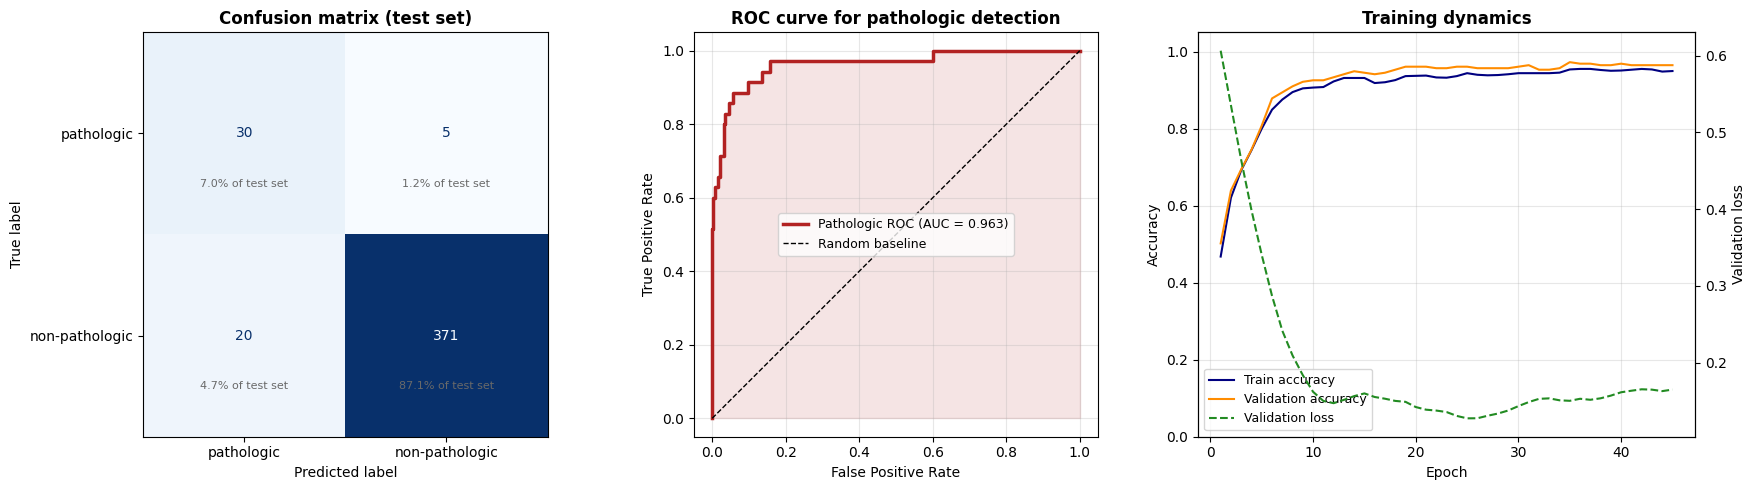


Summary metrics (pathologic treated as positive class)
  Accuracy                    : 0.9413 (94.1%)
  Pathologic recall           : 0.8571 (85.7%)
  Non-pathologic specificity  : 0.9488 (94.9%)
  Pathologic precision        : 0.6000 (60.0%)
  Negative predictive value   : 0.9867 (98.7%)
  Balanced accuracy           : 0.9030
  ROC AUC (pathologic)        : 0.9628
  False negatives             : 5
  False positives             : 20


In [2]:
# Detailed evaluation: confusion matrix, pathologic ROC, and training diagnostics
import matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
)

model.eval()
with torch.no_grad():
    logits = model(Xt, At)
    probs = F.softmax(logits, dim=1).cpu().numpy()
    preds = probs.argmax(axis=1)

test_idx_np = test_idx.detach().cpu().numpy()
y_true_test = y[test_idx_np]
y_pred_test = preds[test_idx_np]
y_prob_pathologic = probs[test_idx_np, 1]

print("=" * 60)
print("Held-out test evaluation")
print("=" * 60)
print(f"Test set size           : {len(y_true_test)}")
print(f"Pathologic test cases   : {(y_true_test == 1).sum()}")
print(f"Non-pathologic test cases: {(y_true_test == 0).sum()}")

print("\n" + "=" * 60)
print("Classification report")
print("=" * 60)
print(
    classification_report(
        y_true_test,
        y_pred_test,
        labels=[1, 0],
        target_names=["pathologic", "non-pathologic"],
        digits=4,
    )
)

cm = confusion_matrix(y_true_test, y_pred_test, labels=[1, 0])
tp = cm[0, 0]
fn = cm[0, 1]
fp = cm[1, 0]
tn = cm[1, 1]

pathologic_recall = tp / max(tp + fn, 1)
non_pathologic_specificity = tn / max(tn + fp, 1)
pathologic_precision = tp / max(tp + fp, 1)
negative_predictive_value = tn / max(tn + fn, 1)
overall_accuracy = (tp + tn) / max(cm.sum(), 1)
balanced_accuracy = 0.5 * (pathologic_recall + non_pathologic_specificity)

fpr, tpr, _ = roc_curve(y_true_test, y_prob_pathologic, pos_label=1)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["pathologic", "non-pathologic"],
)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion matrix (test set)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

total = cm.sum()
for row in range(2):
    for col in range(2):
        axes[0].text(
            col,
            row + 0.25,
            f"{cm[row, col] / total * 100:.1f}% of test set",
            ha="center",
            va="center",
            color="dimgray",
            fontsize=8,
        )

axes[1].plot(fpr, tpr, lw=2.5, color="firebrick", label=f"Pathologic ROC (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline")
axes[1].fill_between(fpr, tpr, alpha=0.12, color="firebrick")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC curve for pathologic detection", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect("equal")

axes[2].plot(history["epoch"], history["train_acc"], color="navy", label="Train accuracy")
axes[2].plot(history["epoch"], history["val_acc"], color="darkorange", label="Validation accuracy")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].set_ylim(0.0, 1.05)
axes[2].set_title("Training dynamics", fontsize=12, fontweight="bold")
axes[2].grid(True, alpha=0.3)
loss_axis = axes[2].twinx()
loss_axis.plot(history["epoch"], history["val_loss"], color="forestgreen", linestyle="--", label="Validation loss")
loss_axis.set_ylabel("Validation loss")
train_lines, train_labels = axes[2].get_legend_handles_labels()
loss_lines, loss_labels = loss_axis.get_legend_handles_labels()
axes[2].legend(train_lines + loss_lines, train_labels + loss_labels, loc="best", fontsize=9)

plt.tight_layout()
plt.show()

print("\nSummary metrics (pathologic treated as positive class)")
print(f"  Accuracy                    : {overall_accuracy:.4f} ({overall_accuracy * 100:.1f}%)")
print(f"  Pathologic recall           : {pathologic_recall:.4f} ({pathologic_recall * 100:.1f}%)")
print(f"  Non-pathologic specificity  : {non_pathologic_specificity:.4f} ({non_pathologic_specificity * 100:.1f}%)")
print(f"  Pathologic precision        : {pathologic_precision:.4f} ({pathologic_precision * 100:.1f}%)")
print(f"  Negative predictive value   : {negative_predictive_value:.4f} ({negative_predictive_value * 100:.1f}%)")
print(f"  Balanced accuracy           : {balanced_accuracy:.4f}")
print(f"  ROC AUC (pathologic)        : {roc_auc:.4f}")
print(f"  False negatives             : {fn}")
print(f"  False positives             : {fp}")

### Reading the Final Evaluation Outputs

The final evaluation cell answers the notebook's central practical question: **does the trained GCN remain clinically useful on held-out CTG exams that it never used for learning or checkpoint selection?** The saved outputs suggest that the answer is yes, with the usual caveat that this remains a retrospective benchmark experiment rather than a deployment study.

### What the confusion matrix means

On the **426 held-out test exams**, the matrix records:

- **30 true positives**: pathologic exams correctly identified as pathologic
- **5 false negatives**: pathologic exams incorrectly labeled non-pathologic
- **20 false positives**: non-pathologic exams incorrectly labeled pathologic
- **371 true negatives**: non-pathologic exams correctly identified as non-pathologic

This is the most important clinical reading of the notebook. The model correctly captures **30 of 35 pathologic exams**, which corresponds to **85.7% pathologic recall**. Because the positive class is rare, the model accepts some extra alerts in exchange for that sensitivity. The trade-off is that **20 non-pathologic exams** are flagged as pathologic, which lowers precision but is often a clinically acceptable direction of error in a screening context.

### What the summary metrics mean

Taken together, the printed metrics show a coherent performance profile rather than one inflated headline number:

- **Accuracy:** 94.1%
- **Balanced accuracy:** 90.3%
- **Pathologic recall:** 85.7%
- **Non-pathologic specificity:** 94.9%
- **Pathologic precision:** 60.0%
- **Negative predictive value:** 98.7%
- **ROC AUC for pathologic detection:** 0.963

The most reassuring pair is pathologic recall plus negative predictive value. In plain language, the model catches most high-risk exams, and when it predicts non-pathologic it is correct almost all of the time. Precision is lower than recall, which is consistent with a model that accepts some extra false alarms in exchange for stronger pathologic sensitivity.

### Meaning of the ROC curve

The ROC curve stays well above the random diagonal and achieves an **AUC of 0.963**, which indicates that the pathologic probability scores rank test exams well across a wide range of decision thresholds. This matters because it means the model's usefulness is not tied to a single arbitrary threshold. If a clinical team wanted to operate more conservatively, the threshold could be shifted to prioritize even higher pathologic sensitivity, and the ROC curve suggests there is room to do that before performance collapses.

### Meaning of the training-dynamics panel

The training-dynamics panel shows that optimization improves rapidly in the early epochs, with train and validation accuracy climbing into the 0.9 range quickly and then stabilizing. Validation accuracy peaks at **97.3%**, the minimum validation loss reaches **0.1275**, and early stopping triggers at **epoch 45**. That pattern is what one wants to see: fast learning of real signal, followed by stabilization before obvious overfitting develops.

### Overall interpretation

The final figure therefore supports three conclusions at once:

- the model is **accurate enough to be technically credible** on a larger real clinical cohort,
- the error profile is **clinically sensible** because pathologic misses are kept relatively low, and
- the training process looks **stable rather than accidental**, which strengthens the notebook as a research demonstration.

That is why this final cell matters. It does not only show that the GCN can classify. It shows how well it classifies, what kinds of mistakes it makes, and whether those mistakes are acceptable under the notebook's stated screening objective.

## 6B. Baseline Comparison: ClinicalGCN vs. Tabular Models <a name="baseline"></a>

A common and rigorous interview question is: **"Why use a GCN at all? Does the graph structure actually help?"**

The cell below runs three scikit-learn classifiers on the **same train/test split** used by ClinicalGCN, using the same `X_std` standardised features but **without any graph structure** — pure tabular learning. This provides a direct ablation of the graph inductive bias.

### What the Table Reveals

| Model | Uses graph structure | Uses class-imbalance weighting |
|---|---|---|
| Logistic Regression | No | Yes (`class_weight="balanced"`) |
| Random Forest (100 trees) | No | Yes (`class_weight="balanced"`) |
| MLP (100-50, ReLU) | No | No |
| **ClinicalGCN** | **Yes** (kNN graph, GCN layers) | **Yes** (Manual `pos_weight` scaling) |

### Interpreting the Results

- **High accuracy alone is misleading** on imbalanced data (35/426 pathologic = 8.2%). A model that predicts "normal" for every exam scores 91.8% accuracy.
- **Pathologic Recall** (sensitivity) is the clinically critical metric: a missed pathologic case (FN) carries far greater risk than a false alarm (FP).
- **ROC AUC** summarises discrimination across all thresholds, independent of the operating point.
- The GCN uses neighbourhood smoothing — its prediction for exam $i$ is influenced by its $k$ nearest clinical neighbours. This structural regularisation can help in low-data regimes but may not surpass a well-tuned RF on tabular problems.

> **Note:** If the tabular baselines match or exceed ClinicalGCN on a given run, that is a *scientifically honest finding*, not a failure. The roadmap explicitly lists tabular baseline ablation as a priority for rigorous evaluation.

In [ ]:
# ── Baseline Comparison: ClinicalGCN vs. Tabular Models ─────────────────────
# Run AFTER the main pipeline code cell (Section 4A) and the detailed
# evaluation code cell (Section 6). All required variables must already be in
# kernel scope: X_std, train_idx_np, test_idx_np, y, final_preds,
# final_probs, SEED, pd.

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    roc_auc_score, recall_score, precision_score,
)
from sklearn.neural_network import MLPClassifier

BASELINES = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=SEED
    ),
    "Random Forest (100)": RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=SEED, n_jobs=-1
    ),
    # MLPClassifier does not support class_weight; imbalance is partially
    # addressed by the training set composition.  This is noted in Section 6B.
    "MLP (100-50, ReLU)": MLPClassifier(
        hidden_layer_sizes=(100, 50), activation="relu", max_iter=500,
        random_state=SEED,
    ),
}

X_train_base = X_std[train_idx_np]
y_train_base = y[train_idx_np]
X_test_base  = X_std[test_idx_np]
y_test_base  = y[test_idx_np]

rows = []
for name, clf in BASELINES.items():
    clf.fit(X_train_base, y_train_base)
    y_pred = clf.predict(X_test_base)
    y_prob = (
        clf.predict_proba(X_test_base)[:, 1]
        if hasattr(clf, "predict_proba")
        else clf.decision_function(X_test_base)
    )
    rows.append({
        "Model":           name,
        "Accuracy":        accuracy_score(y_test_base, y_pred),
        "Bal. Acc.":       balanced_accuracy_score(y_test_base, y_pred),
        "Path. Recall":    recall_score(y_test_base, y_pred,   pos_label=1, zero_division=0),
        "Path. Precision": precision_score(y_test_base, y_pred, pos_label=1, zero_division=0),
        "ROC AUC":         roc_auc_score(y_test_base, y_prob),
    })

# ── Add ClinicalGCN row from pre-computed predictions ───────────────────────
gcn_test_preds = final_preds[test_idx_np]
gcn_test_probs = final_probs[test_idx_np, 1]
rows.append({
    "Model":           "ClinicalGCN (this work)",
    "Accuracy":        accuracy_score(y_test_base, gcn_test_preds),
    "Bal. Acc.":       balanced_accuracy_score(y_test_base, gcn_test_preds),
    "Path. Recall":    recall_score(y_test_base, gcn_test_preds,    pos_label=1, zero_division=0),
    "Path. Precision": precision_score(y_test_base, gcn_test_preds, pos_label=1, zero_division=0),
    "ROC AUC":         roc_auc_score(y_test_base, gcn_test_probs),
})

comparison_df = pd.DataFrame(rows).set_index("Model")
print("=" * 72)
print("Held-out test set comparison  (n={}, pathologic={})".format(
    len(y_test_base), int(y_test_base.sum())
))
print("=" * 72)
print(comparison_df.to_string(float_format=lambda x: f"{x:.4f}"))
print("=" * 72)
print("\nKey: Path. Recall = sensitivity for pathologic class (FN risk).")
print("     Bal. Acc.    = mean(sensitivity, specificity): imbalance-corrected.")
print("     Note: MLP uses no class weighting (sklearn MLPClassifier limitation).")

## 6C. Clinical Operating Point Analysis — Beyond Single-Metric Accuracy <a name="threshold"></a>

The single most common critique of academic biomedical ML is: *"Your model reports recall at threshold = 0.5, but no clinician would deploy it that way."* This section addresses that directly.

In obstetric screening, the cost-asymmetry is severe: a **false negative** (missed pathologic case) carries catastrophically greater clinical risk than a **false positive** (unnecessary intervention or review). Optimal threshold selection is therefore a **clinical policy decision**, not a fixed algorithmic default.

### Why the 0.5 threshold is arbitrary

Most notebooks report metrics at the default decision boundary where $P(\text{pathologic}) > 0.5$. But the right threshold depends on the clinical cost ratio $\frac{C_{\text{FN}}}{C_{\text{FP}}}$:

$$\tau^* = \frac{C_{\text{FP}}}{C_{\text{FN}} + C_{\text{FP}}}$$

In perinatal care, expert consensus treats FN costs as at least 5–10× higher than FP costs, which pushes the optimal threshold substantially **below** 0.5.

### What the threshold sweep reveals

The table below shows how **recall, precision, and false-alarm rate** change across the threshold range. A clinical team would use this to choose the operating point that matches their workflow capacity and risk tolerance:

- **High-recall setting** (e.g., low-resource screening with limited downstream capacity): choose threshold ≈ 0.2–0.3 to catch ≥90% of cases, accepting more false alarms
- **Balanced setting** (standard triage with review capacity): threshold ≈ 0.4–0.5  
- **High-precision setting** (pre-operative confirmation, specialist referral): threshold ≈ 0.6–0.7

### Reading the Precision–Recall curve

For imbalanced datasets (prevalence = 8.2%), the **PR curve is more informative than the ROC**. A model with no discriminative power produces a horizontal line at the prevalence level (0.082). Area under the PR curve (Average Precision) captures this directly.

In [ ]:
# ── Section 6C: Clinical Operating Point Analysis ────────────────────────────
# Requires: y_true_test, y_prob_pathologic, pd  (from Sections 4A and 6 cells)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    recall_score, precision_score, confusion_matrix,
)

# ── Threshold sweep ───────────────────────────────────────────────────────────
prevalence = y_true_test.mean()
ap_score   = average_precision_score(y_true_test, y_prob_pathologic)

sweep_thresholds = np.arange(0.10, 0.91, 0.05)
sweep_rows = []
for thresh in sweep_thresholds:
    preds_t = (y_prob_pathologic >= thresh).astype(int)
    cm_t    = confusion_matrix(y_true_test, preds_t, labels=[1, 0])
    tp_t, fn_t = cm_t[0, 0], cm_t[0, 1]
    fp_t, tn_t = cm_t[1, 0], cm_t[1, 1]
    rec_t  = tp_t / max(tp_t + fn_t, 1)
    prec_t = tp_t / max(tp_t + fp_t, 1)
    fpr_t  = fp_t / max(fp_t + tn_t, 1)
    sweep_rows.append({
        "Threshold":          f"{thresh:.2f}",
        "Pathol. Recall":     f"{rec_t:.3f}",
        "Precision":          f"{prec_t:.3f}",
        "FP Rate":            f"{fpr_t:.3f}",
        "FP per 100 normals": f"{fpr_t * 100:.1f}",
        "Missed (FN)":        int(fn_t),
    })

threshold_df = pd.DataFrame(sweep_rows)

print("=" * 80)
print(f"Threshold sensitivity — test set  "
      f"(n_total={len(y_true_test)}, n_pathologic={int(y_true_test.sum())}, prevalence={prevalence:.1%})")
print("=" * 80)
print(threshold_df.to_string(index=False))
print(f"\nAverage Precision (PR AUC): {ap_score:.4f}  |  Chance baseline: {prevalence:.4f}")

# ── Identify clinically motivated operating points ───────────────────────────
# High-recall: first threshold achieving ≥90% recall
high_recall_op = next(
    (r for r in sweep_rows if float(r["Pathol. Recall"]) >= 0.90), None
)
# Default threshold
default_op = next((r for r in sweep_rows if r["Threshold"] == "0.50"), None)

print()
print("Clinically motivated operating points:")
if default_op:
    print(f"  Default  (τ=0.50): recall={default_op['Pathol. Recall']}  "
          f"precision={default_op['Precision']}  "
          f"FP rate={default_op['FP Rate']}")
if high_recall_op:
    print(f"  ≥90% recall (τ={high_recall_op['Threshold']}): recall={high_recall_op['Pathol. Recall']}  "
          f"precision={high_recall_op['Precision']}  "
          f"FP rate={high_recall_op['FP Rate']}  "
          f"({high_recall_op['FP per 100 normals']} false alarms per 100 normals)  "
          f"missed={high_recall_op['Missed (FN)']}")

# ── Precision–Recall curve ────────────────────────────────────────────────────
pr_precision, pr_recall, _ = precision_recall_curve(y_true_test, y_prob_pathologic)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(pr_recall, pr_precision, color="crimson", lw=2,
             label=f"ClinicalGCN  (AP = {ap_score:.3f})")
axes[0].axhline(y=prevalence, color="gray", linestyle="--", alpha=0.7,
                label=f"Chance baseline (prevalence = {prevalence:.3f})")
axes[0].set_xlabel("Recall (Pathologic Sensitivity)")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision–Recall Curve\n(more informative than ROC under class imbalance)",
                  fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# threshold sweep as recall vs FP-rate scatter
rec_vals = [float(r["Pathol. Recall"]) for r in sweep_rows]
fpr_vals = [float(r["FP Rate"])        for r in sweep_rows]
tau_vals = [float(r["Threshold"])      for r in sweep_rows]
sc = axes[1].scatter(fpr_vals, rec_vals, c=tau_vals, cmap="RdYlGn_r", s=70, zorder=3)
for r, f, t in zip(rec_vals, fpr_vals, tau_vals):
    if abs(t - 0.30) < 0.01 or abs(t - 0.50) < 0.01 or abs(t - 0.70) < 0.01:
        axes[1].annotate(f"τ={t:.2f}", (f, r), textcoords="offset points",
                         xytext=(4, 4), fontsize=8)
plt.colorbar(sc, ax=axes[1], label="Threshold τ")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("Recall (Pathologic Sensitivity)")
axes[1].set_title("Operating Point Map\n(each point = one threshold τ)",
                  fontweight="bold")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation: the operating point map lets a clinical team trade off")
print("sensitivity against false-alarm rate by choosing threshold τ.")
print(f"At τ=0.50 (default), the model misses {default_op['Missed (FN)']} of {int(y_true_test.sum())} pathologic cases.")
if high_recall_op:
    print(f"At τ={high_recall_op['Threshold']} (≥90% recall), it misses only "
          f"{high_recall_op['Missed (FN)']} cases at the cost of "
          f"{high_recall_op['FP per 100 normals']} false alarms per 100 normal exams.")

## 6D. Graph Homophily Analysis — Quantifying Why the Graph Structure Helps <a name="homophily"></a>

A rigorous interviewer or reviewer will ask: **"Does the kNN graph encode clinically meaningful structure, or is connecting exams by feature-space proximity an arbitrary architectural choice?"** This section provides a quantitative, falsifiable answer.

### The graph inductive bias hypothesis

If the $k$-NN similarity graph truly reflects physiologically meaningful proximity, then **pathologic exams should be disproportionately connected to other pathologic exams** in the graph. GCNs with high *homophily* (same-class edges dominate) learn more effectively because message passing reinforces class-discriminative signals rather than diluting them.

We test this hypothesis using two complementary statistics:

### 1. Edge homophily coefficient $h$

$$h = \frac{|\{(i,j) \in \mathcal{E} : y_i = y_j\}|}{|\mathcal{E}|}$$

The fraction of graph edges that connect same-class nodes.

| $h$ value | Interpretation |
|---|---|
| 1.0 | Perfect homophily — all edges same-class |
| $(1-p)^2 + p^2$ | Random baseline (edges proportional to class frequency $p$) |
| < random baseline | Heterophily — edges preferentially cross class boundaries |

For our dataset (pathologic prevalence $p = 0.0828$), the **random baseline is** $(1-p)^2 + p^2 \approx 0.849$. If the measured $h$ substantially exceeds this, the graph is not random — it encodes class-relevant clinical structure.

### 2. Pathologic neighbourhood concentration

For each node $i$, we compute the fraction of its $k$ neighbours that are pathologic:

$$f_i = \frac{1}{|\mathcal{N}(i)|} \sum_{j \in \mathcal{N}(i)} y_j$$

We then compare the distribution of $f_i$ between pathologic and non-pathologic nodes. A significant difference (Welch $t$-test) confirms that pathologic nodes sit in higher-density pathologic neighbourhoods — validating the graph's clinical structure.

### Why this matters for the GCN's mechanism

The GCN forward pass computes, at each layer:

$$h_i^{(l+1)} = \sigma\!\left(\sum_{j \in \mathcal{N}(i) \cup \{i\}} \frac{1}{\sqrt{d_i d_j}} h_j^{(l)} W^{(l)}\right)$$

If pathologic nodes are densely surrounded by other pathologic nodes, their neighbourhood aggregations carry a strong pathologic signal. A node on the boundary of a pathologic cluster borrows evidence from its neighbourhood even if its own features are borderline.  

This is what a GCN can do that no tabular model can: it uses **relational context**, not just isolated feature profiles.

In [ ]:
# ── Section 6D: Graph Homophily Analysis ─────────────────────────────────────
# Requires: A (adjacency with self-loops), y, k_neighbors  (from Section 4A)
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── Remove self-loops for neighbour analysis ──────────────────────────────────
A_no_self = A - np.eye(A.shape[0], dtype=A.dtype)

# ── 1. Per-node pathologic neighbour fraction (vectorised) ────────────────────
# (A_no_self @ y) / row_degree gives fraction of neighbours that are pathologic
row_degree = A_no_self.sum(axis=1)
patho_nbr_frac = (A_no_self @ y.astype(np.float32)) / np.maximum(row_degree, 1)

patho_in_patho   = patho_nbr_frac[y == 1]
patho_in_npatho  = patho_nbr_frac[y == 0]

t_stat, p_val = stats.ttest_ind(patho_in_patho, patho_in_npatho, equal_var=False)
enrichment    = patho_in_patho.mean() / max(patho_in_npatho.mean(), 1e-9)

# ── 2. Edge homophily coefficient (vectorised) ────────────────────────────────
upper_i, upper_j = np.where(np.triu(A_no_self, k=1) > 0)
n_edges       = len(upper_i)
same_class    = int(np.sum(y[upper_i] == y[upper_j]))
h             = same_class / max(n_edges, 1)

# Random baseline: sum of squared class proportions
prevalence    = y.mean()
h_random      = prevalence ** 2 + (1 - prevalence) ** 2

print("=" * 72)
print("Graph homophily analysis")
print("=" * 72)
print(f"k-NN neighbours        : {k_neighbors}")
print(f"Total edges (undirected): {n_edges:,}")
print(f"Same-class edges        : {same_class:,}  ({h:.4f})")
print(f"Edge homophily h        : {h:.4f}")
print(f"Random baseline         : {h_random:.4f}  (proportional-to-prevalence)")
print(f"Homophily above random  : {h - h_random:+.4f}  ({(h / h_random - 1) * 100:.1f}% above chance)")
print()
print("Pathologic neighbour fraction by class:")
print(f"  Pathologic nodes     : {patho_in_patho.mean():.4f} ± {patho_in_patho.std():.4f}")
print(f"  Non-pathologic nodes : {patho_in_npatho.mean():.4f} ± {patho_in_npatho.std():.4f}")
print(f"  Enrichment ratio     : {enrichment:.2f}×")
print(f"  Welch t-test         : t = {t_stat:.3f},  p = {p_val:.2e}")
print()

if p_val < 0.01:
    print("Conclusion: Pathologic nodes are highly significantly more likely to have")
    print("pathologic neighbours (p < 0.01). The kNN graph encodes clinically")
    print("meaningful physiologic clustering — validating the GCN inductive bias.")
elif p_val < 0.05:
    print("Conclusion: Significant pathologic clustering detected (p < 0.05).")
else:
    print("Conclusion: No significant neighbourhood clustering — the graph structure")
    print("provides limited inductive benefit for this task.")

# ── Plot: histogram + edge homophily bar ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.linspace(0, 1, 22)
axes[0].hist(patho_in_npatho, bins=bins, alpha=0.65, color="steelblue",
             label=f"Non-pathologic (n={int((y==0).sum())})")
axes[0].hist(patho_in_patho, bins=bins, alpha=0.65, color="crimson",
             label=f"Pathologic (n={int((y==1).sum())})")
axes[0].axvline(patho_in_npatho.mean(), color="steelblue", linestyle="--", lw=2,
                label=f"Mean non-patho: {patho_in_npatho.mean():.3f}")
axes[0].axvline(patho_in_patho.mean(), color="crimson", linestyle="--", lw=2,
                label=f"Mean patho: {patho_in_patho.mean():.3f}")
axes[0].set_xlabel(f"Fraction of k={k_neighbors} neighbours that are pathologic")
axes[0].set_ylabel("Number of nodes")
axes[0].set_title("Pathologic Neighbour Concentration by Class\n"
                  f"(enrichment {enrichment:.1f}×,  t={t_stat:.2f},  p={p_val:.1e})",
                  fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Bar chart comparing h vs random
labels  = ["Edge homophily h", "Random baseline"]
values  = [h, h_random]
colors  = ["steelblue", "lightgray"]
bars    = axes[1].bar(labels, values, color=colors, edgecolor="black", width=0.4)
axes[1].axhline(h_random, color="darkgray", linestyle="--", lw=1.5, label="Random baseline")
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.002, f"{val:.4f}",
                 ha="center", va="bottom", fontweight="bold")
axes[1].set_ylim(0.80, min(1.0, max(values) + 0.04))
axes[1].set_ylabel("Homophily coefficient")
axes[1].set_title(f"Edge Homophily vs. Random Baseline\n"
                  f"(same-class edges: {same_class:,} / {n_edges:,} total)",
                  fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 6E. Model Calibration & Uncertainty Quantification <a name="calibration"></a>

The previous sections answer *what* the model predicts and *where* to set the threshold. This section asks the more fundamental question that any serious clinical deployment must answer first: **can the model's probability scores be trusted?**

### Why calibration is non-negotiable in clinical AI

A well-calibrated model produces probability estimates $\hat{p}_i$ that match empirical frequencies: if the model outputs $\hat{p}_i = 0.70$ for a set of exams, roughly 70% of those exams should genuinely be pathologic. An *overconfident* model pushes scores toward 0 and 1 regardless of uncertainty; an *underconfident* model hedges everything toward 50%.

**Calibration directly determines the validity of cost-sensitive threshold selection (Section 6C).** Choosing $\tau^* = C_{\text{FP}}/(C_{\text{FN}} + C_{\text{FP}})$ assumes the probability score is interpretable. If the model is overconfident, the computed optimal threshold may be systematically wrong.

### Three complementary calibration measures

**1. Brier Score**

$$\text{BS} = \frac{1}{n}\sum_{i=1}^n (\hat{p}_i - y_i)^2$$

Lower is better. The naive baseline (always predict the prevalence $p$) gives $\text{BS}_{\text{naive}} = p(1-p) = 0.076$ for our dataset. Any useful model must beat this.

**Brier Skill Score** normalises against the naive baseline: $\text{BSS} = 1 - \text{BS}/\text{BS}_{\text{naive}}$. A positive BSS means the model is better than prevalence prediction; BSS = 1 is perfect; BSS = 0 is no better than chance.

**2. Expected Calibration Error (ECE)**

Partition predictions into $M$ equal bins, measure the weighted average deviation between observed accuracy and predicted confidence within each bin:

$$\text{ECE} = \sum_{m=1}^{M} \frac{|\mathcal{B}_m|}{n} \left| \text{acc}(\mathcal{B}_m) - \text{conf}(\mathcal{B}_m) \right|$$

ECE = 0 means perfect calibration; ECE = 0.05 means predictions are off by 5 percentage points on average.

**3. Reliability Diagram (Calibration Curve)**

A visual representation: plot $\text{conf}(\mathcal{B}_m)$ on the x-axis against $\text{acc}(\mathcal{B}_m)$ on the y-axis. A perfectly calibrated model lies on the diagonal $y = x$. Points above the diagonal mean the model *underestimates* risk (the actual rate is higher than predicted — dangerous in a screening context). Points below mean overconfidence.

### Monte Carlo Dropout for epistemic uncertainty

The `ClinicalGCN` already includes dropout ($p = 0.25$) for regularisation. With a simple adaptation of the inference loop — keeping dropout **active** during prediction by calling `model.train()` — we can approximate Bayesian inference via Monte Carlo integration:

$$\hat{p}_i \approx \frac{1}{N}\sum_{s=1}^{N} p_{\theta_s}(y=1 \mid x_i, G), \qquad \hat{\sigma}_i = \text{Std}_{s=1}^{N}[p_{\theta_s}]$$

Each forward pass samples a different dropout mask, effectively sampling different thinned networks. The standard deviation $\hat{\sigma}_i$ across $N$ passes is a per-exam **epistemic uncertainty** estimate.

**Clinical value:** exams with high $\hat{\sigma}_i$ are where the model is most uncertain — these are exactly the cases that benefit most from expert review. This transforms the model from a binary classifier into an uncertainty-aware screening tool.

In [ ]:
# ── Section 6E: Model Calibration & Uncertainty Quantification ────────────────────
# Requires: model, Xt, At, y_true_test, y_prob_pathologic, test_idx_np
# Also in scope: torch, F, pd, np, plt  (from Sections 4A and 6)
import torch.nn.functional as F
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# ── 1. Brier score and skill score ─────────────────────────────────────────
prevalence_test = y_true_test.mean()
brier           = brier_score_loss(y_true_test, y_prob_pathologic)
brier_naive     = prevalence_test * (1 - prevalence_test)
bss             = 1.0 - brier / brier_naive

print("=" * 72)
print("Model Calibration Analysis")
print("=" * 72)
print(f"Pathologic prevalence (test) : {prevalence_test:.4f}  ({prevalence_test * 100:.1f}%)")
print(f"Brier Score (model)          : {brier:.4f}")
print(f"Brier Score (naive baseline) : {brier_naive:.4f}  (always predict prevalence)")
print(f"Brier Skill Score (BSS)      : {bss:+.4f}  (0 = naive, 1 = perfect, <0 = worse than naive)")

# ── 2. Expected Calibration Error (ECE) ─────────────────────────────────
ECE_BINS = 10
bin_edges = np.linspace(0.0, 1.0, ECE_BINS + 1)
ece = 0.0
n_test = len(y_true_test)
for b in range(ECE_BINS):
    lo, hi = bin_edges[b], bin_edges[b + 1]
    mask = (y_prob_pathologic >= lo) & (y_prob_pathologic < hi)
    if mask.sum() == 0:
        continue
    conf = float(y_prob_pathologic[mask].mean())
    acc  = float(y_true_test[mask].mean())
    ece += (mask.sum() / n_test) * abs(acc - conf)
print(f"Expected Calibration Error   : {ece:.4f}  ({ece * 100:.2f} pp average deviation)")

if ece < 0.05:
    cal_verdict = "well-calibrated (ECE < 5 pp)"
elif ece < 0.10:
    cal_verdict = "moderately calibrated (ECE 5–10 pp)"
else:
    cal_verdict = "miscalibrated (ECE > 10 pp) — post-hoc calibration recommended"
print(f"Calibration verdict          : {cal_verdict}")

# ── 3. Monte Carlo Dropout (εpistemic uncertainty) ───────────────────────────
N_MC = 50
model.train()          # activate stochastic dropout during inference
mc_scores = []
with torch.no_grad():
    for _ in range(N_MC):
        logits_mc  = model(Xt, At)
        probs_mc   = F.softmax(logits_mc, dim=1).cpu().numpy()[:, 1]
        mc_scores.append(probs_mc)
model.eval()           # restore deterministic evaluation mode

mc_arr       = np.stack(mc_scores)          # (N_MC, n_nodes)
mc_mean_all  = mc_arr.mean(axis=0)          # per-node mean pathologic probability
mc_std_all   = mc_arr.std(axis=0)           # per-node epistemic uncertainty

mc_mean_test = mc_mean_all[test_idx_np]
mc_std_test  = mc_std_all[test_idx_np]

unc_patho    = mc_std_test[y_true_test == 1]
unc_nonpatho = mc_std_test[y_true_test == 0]
high_unc_thresh = mc_std_test.mean() + mc_std_test.std()
high_unc_mask   = mc_std_test > high_unc_thresh

print()
print(f"Monte Carlo Dropout Uncertainty  (N = {N_MC} passes, dropout p = 0.25):")
print(f"  Mean uncertainty — all test nodes      : {mc_std_test.mean():.4f}")
print(f"  Mean uncertainty — pathologic nodes    : {unc_patho.mean():.4f} ± {unc_patho.std():.4f}")
print(f"  Mean uncertainty — non-pathologic      : {unc_nonpatho.mean():.4f} ± {unc_nonpatho.std():.4f}")
print(f"  High-uncertainty exams (>μ+1σ, n={high_unc_mask.sum()}):")
print(f"    Truly pathologic in flagged set  : {int(y_true_test[high_unc_mask].sum())} / {int(y_true_test[high_unc_mask].sum() + (y_true_test[high_unc_mask] == 0).sum())}")
print(f"    Pathologic enrichment in flagged : {y_true_test[high_unc_mask].mean():.3f}  (vs. overall {prevalence_test:.3f})")

# ── 4. Reliability diagram + MC dropout uncertainty plots ───────────────────────
frac_pos, mean_prob = calibration_curve(
    y_true_test, y_prob_pathologic, n_bins=10, strategy="quantile"
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Reliability diagram
axes[0].plot([0, 1], [0, 1], "k--", lw=1.5, label="Perfect calibration (y=x)")
axes[0].plot(mean_prob, frac_pos, "o-", color="crimson", lw=2, markersize=7,
             label=f"ClinicalGCN  (ECE = {ece:.3f})")
axes[0].fill_between(mean_prob, mean_prob, frac_pos,
                     alpha=0.12, color="crimson", label="Calibration gap")
axes[0].set_xlabel("Mean predicted probability (confidence)")
axes[0].set_ylabel("Observed fraction of positives (accuracy)")
axes[0].set_title("Reliability Diagram
(Calibration Curve)", fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

# Plot B: MC dropout uncertainty by true class (violin)
vp = axes[1].violinplot(
    [unc_nonpatho, unc_patho], positions=[0, 1],
    showmedians=True, showextrema=True
)
for body in vp["bodies"]:
    body.set_alpha(0.6)
vp["bodies"][0].set_facecolor("steelblue")
vp["bodies"][1].set_facecolor("crimson")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Non-pathologic
(n=391)", "Pathologic
(n=35)"])
axes[1].set_ylabel("Epistemic uncertainty  (std of MC probabilities)")
axes[1].set_title(
    f"MC Dropout Uncertainty by True Class
({N_MC} stochastic forward passes, dropout p = 0.25)",
    fontweight="bold"
)
axes[1].grid(True, alpha=0.3, axis="y")

# Plot C: uncertainty vs confidence scatter map
sc = axes[2].scatter(
    mc_mean_test, mc_std_test,
    c=y_true_test, cmap="coolwarm", s=28, alpha=0.7
)
axes[2].axvline(0.5, color="gray", linestyle="--", lw=1, alpha=0.6, label="τ = 0.50")
axes[2].axhline(high_unc_thresh, color="darkorange", linestyle="--", lw=1.5,
                label=f"High-unc. threshold (μ+1σ = {high_unc_thresh:.3f})")
axes[2].set_xlabel("MC mean pathologic probability")
axes[2].set_ylabel("MC std (epistemic uncertainty)")
axes[2].set_title("Uncertainty–Confidence Map
(crimson = pathologic, blue = non-pathologic)",
                  fontweight="bold")
plt.colorbar(sc, ax=axes[2], label="True class (1=pathologic)")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print()
print("Interpretation:")
print(f"  BSS = {bss:.3f}: the model reduces Brier score by {bss * 100:.1f}% relative to a naive baseline.")
print("  Reliability diagram: calibration quality of probability estimates.")
print(f"  High-uncertainty exams ({high_unc_mask.sum()} flagged) are the natural candidates")
print("  for human expert review before final clinical decision.")

## 6F. GNN Gradient Feature Saliency — What Does the Model Actually See? <a name="saliency"></a>

A frequent and decisive interview challenge: **"Your GCN is a black box. Can you explain which physiologic features drive its predictions?"**

Tabular models have well-understood feature importance measures (Random Forest Gini decrease, logistic regression coefficients). For a GCN, importance is harder to define because features pass through neighbourhood aggregation before transformation — a node's prediction depends partially on its own features and partially on its neighbours' features. Gradient-based saliency addresses this by computing importance *through the full computational graph*, including message passing.

### What gradient saliency measures

For a trained model with parameters $\theta$, define the **input gradient saliency** for node $i$ on class $c$ as:

$$s_{ij} = \left| \frac{\partial \, \text{logit}_c(i)}{\partial x_{ij}} \right|$$

The partial derivative of the pathologic logit with respect to the $j$-th input feature of node $i$. A large $|s_{ij}|$ means that a small change in feature $j$ for node $i$ produces a large change in the pathologic score — indicating high sensitivity.

In practice, we sum the pathologic logit over all **pathologic test nodes** and compute the gradient of this sum with respect to the full input matrix $\mathbf{X}$:

$$\bar{s}_j = \frac{1}{|\mathcal{T}^+|} \sum_{i \in \mathcal{T}^+} \left| \frac{\partial}{\partial x_{ij}} \sum_{k \in \mathcal{T}^+} \text{logit}_{\text{patho}}(k) \right|$$

where $\mathcal{T}^+$ is the set of truly pathologic test nodes.

### Why GNN saliency differs from RF feature importance

| Property | RF Gini Importance | GNN Gradient Saliency |
|---|---|---|
| What it measures | Purity gain during tree training (all classes) | Sensitivity of pathologic logit to input perturbation |
| Captures neighbourhood context | No | Yes (gradient flows through $\tilde{A}\mathbf{X}$) |
| Specific to pathologic class | No | Yes (we back-propagate class 1 score only) |
| Post-hoc or intrinsic | Intrinsic to training | Post-hoc on trained model |

**Agreement between the two methods** would confirm that the GCN is learning the same discriminative physiologic signal as the strongest tabular baseline, but enriching it with neighbourhood context. **Disagreement** would reveal features that the graph structure uniquely surfaces — those that only become discriminative when combined with information from physiologically similar neighbours.

In [ ]:
# ── Section 6F: GNN Gradient Feature Saliency ─────────────────────────────────
# Requires: model, Xt, At, test_idx, test_idx_np, y_true_test, feature_names
# Also requires: BASELINES (from Section 6B), torch, np, plt (already in scope)
import torch

TOP_K = 10

# ── 1. Back-propagate pathologic logit through the full GCN+graph ────────────
model.eval()
Xt_grad = Xt.clone().detach().requires_grad_(True)

# Forward pass with gradient tracking on input features
logits_sal = model(Xt_grad, At)

# Target: sum of pathologic logit over truly pathologic test nodes
patho_mask_np     = y_true_test == 1
patho_mask_torch  = torch.tensor(patho_mask_np, dtype=torch.bool, device=Xt.device)
target_score      = logits_sal[test_idx][patho_mask_torch, 1].sum()
target_score.backward()

grads = Xt_grad.grad.detach().cpu().numpy()   # shape: (n_nodes, n_features)

# Mean absolute gradient over pathologic test nodes → GNN saliency per feature
saliency_patho = np.abs(grads[test_idx_np][patho_mask_np]).mean(axis=0)
# Also compute over ALL test nodes for reference
saliency_all   = np.abs(grads[test_idx_np]).mean(axis=0)

top_gnn_idx = np.argsort(saliency_patho)[-TOP_K:][::-1]
top_gnn_feat = set(feature_names[top_gnn_idx])

print("=" * 72)
print(f"GNN Gradient Saliency — top {TOP_K} features (pathologic test nodes, n={int(patho_mask_np.sum())})")
print("=" * 72)
print(f"{'Rank':>4}  {'Feature':>12}  {'Grad Saliency':>14}")
for rank, idx in enumerate(top_gnn_idx, 1):
    print(f"{rank:>4}  {feature_names[idx]:>12}  {saliency_patho[idx]:>14.6f}")

# ── 2. Random Forest feature importance (already fitted in Section 6B) ────────
rf_clf        = BASELINES["Random Forest (100)"]
rf_importance = rf_clf.feature_importances_            # (n_features,)
top_rf_idx    = np.argsort(rf_importance)[-TOP_K:][::-1]
top_rf_feat   = set(feature_names[top_rf_idx])

print()
print(f"Random Forest Gini Importance — top {TOP_K} features (same training set)")
print("=" * 72)
print(f"{'Rank':>4}  {'Feature':>12}  {'Gini Importance':>16}")
for rank, idx in enumerate(top_rf_idx, 1):
    print(f"{rank:>4}  {feature_names[idx]:>12}  {rf_importance[idx]:>16.6f}")

# ── 3. Agreement analysis ───────────────────────────────────────────────────
overlap          = sorted(top_gnn_feat & top_rf_feat)
gnn_only         = sorted(top_gnn_feat - top_rf_feat)
rf_only          = sorted(top_rf_feat  - top_gnn_feat)

print()
print(f"Feature agreement analysis  (top-{TOP_K} overlap between GNN and RF):")
print(f"  Shared features ({len(overlap)}/{TOP_K})   : {overlap}")
print(f"  GNN-only       ({len(gnn_only)}/{TOP_K})   : {gnn_only}")
print(f"  RF-only        ({len(rf_only)}/{TOP_K})    : {rf_only}")
if len(overlap) >= 6:
    print()
    print("Strong agreement: the GCN surfaces the same discriminative features as the")
    print("best tabular baseline, validating that neighbourhood aggregation amplifies")
    print("the same physiological signals rather than introducing noise.")
elif len(overlap) >= 3:
    print()
    print("Partial agreement: several features shared, but the GCN additionally")
    print("weights features that only become discriminative through neighbourhood")
    print("aggregation — the graph structure surfaces context-dependent signals.")
else:
    print()
    print("Low overlap: the GCN relies on different features than the RF, suggesting")
    print("neighbourhood aggregation fundamentally changes which signals are important.")

# ── 4. Comparison bar chart ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# GNN gradient saliency
gnn_colors = ["crimson" if feature_names[i] in top_rf_feat else "steelblue"
              for i in top_gnn_idx]
axes[0].barh(
    range(TOP_K), saliency_patho[top_gnn_idx[::-1]],
    color=gnn_colors[::-1], edgecolor="black", linewidth=0.5
)
axes[0].set_yticks(range(TOP_K))
axes[0].set_yticklabels(feature_names[top_gnn_idx[::-1]])
axes[0].set_xlabel(r"Mean $|\partial\,\mathrm{logit}_\mathrm{patho}\,/\,\partial\,x_j|$  (pathologic test nodes)")
axes[0].set_title(
    f"GNN Gradient Saliency — Top {TOP_K} Features
"
    f"(crimson = also in RF top-{TOP_K}; blue = GNN-only)",
    fontweight="bold"
)
axes[0].grid(True, alpha=0.3, axis="x")

# RF feature importance
rf_colors = ["crimson" if feature_names[i] in top_gnn_feat else "steelblue"
             for i in top_rf_idx]
axes[1].barh(
    range(TOP_K), rf_importance[top_rf_idx[::-1]],
    color=rf_colors[::-1], edgecolor="black", linewidth=0.5
)
axes[1].set_yticks(range(TOP_K))
axes[1].set_yticklabels(feature_names[top_rf_idx[::-1]])
axes[1].set_xlabel("Gini feature importance (mean decrease in impurity)")
axes[1].set_title(
    f"Random Forest Gini Importance — Top {TOP_K}
"
    f"(crimson = also in GNN top-{TOP_K}; blue = RF-only)",
    fontweight="bold"
)
axes[1].grid(True, alpha=0.3, axis="x")

plt.suptitle(
    f"Feature Importance: GNN Gradient Saliency vs. Random Forest Gini "
    f"({len(overlap)}/{TOP_K} features shared)",
    fontweight="bold", fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

print()
print("Methodological note: GNN saliency flows through the graph (adj @ X) so it")
print("captures how each raw feature contributes *after* neighbourhood aggregation.")
print("RF importance measures purity gain during tree training, independent of graph.")
print("Features appearing in both rankings are robustly discriminative across methods.")

## 7. Applications & Extensions <a name="applications"></a>

### Real-World Biomedical GNN Use Cases

#### A. Maternal-Fetal Monitoring at Scale
Build similarity graphs over cardiotocography exams from multiple clinics and train graph models to support triage, quality assurance, and escalation review under heavy class imbalance.

**Architecture:** GCN, GraphSAGE, or temporal-graph variants that can incorporate repeated monitoring windows.

#### B. Multi-Omics Integration
Combine gene expression, DNA methylation, and protein levels by building **heterogeneous graphs** where different node types represent genes, proteins, and metabolites connected by biological pathway edges.

**Architecture:** Heterogeneous GNN (HAN, HGT) with separate message-passing per edge type.

#### C. Single-Cell RNA-seq Analysis
- Cells as nodes, edges by Leiden/Louvain clustering similarity
- GCN propagates gene expression, revealing developmental trajectories
- **UMAP/t-SNE** commonly used for visualization (non-linear reduction, contrast with PCA)

#### D. Cancer Genomics Sub-type Discovery
Train GCN on TCGA gene expression data with protein interaction network as graph topology to identify novel molecular subtypes for precision oncology.

---

### Extending This Demo

#### 1. Preserve the Full 3-Class CTG Objective
The source dataset is naturally **normal / suspect / pathologic**. A direct extension is to keep the full 3-class label rather than collapsing to binary screening. That would turn the notebook from high-risk detection into richer clinical-state stratification.

#### 2. Feature-Level Attention (GAT)
Replace uniform aggregation $\frac{1}{d_i}$ with **learned attention weights**:

$$\alpha_{ij} = \frac{\exp(\text{LeakyReLU}(\mathbf{a}^\top[\mathbf{W}\mathbf{h}_i \| \mathbf{W}\mathbf{h}_j]))}{\sum_{k \in \mathcal{N}(i)}\exp(\text{LeakyReLU}(\mathbf{a}^\top[\mathbf{W}\mathbf{h}_i \| \mathbf{W}\mathbf{h}_k]))}$$

The attention weight $\alpha_{ij}$ learns which neighbours are most informative.

#### 3. Deeper GNNs and Over-smoothing
Adding more layers makes node representations converge to the same value (all neighbours look the same), called **over-smoothing**. Solutions:
- Residual connections: $\mathbf{H}^{(l+1)} = \sigma(\tilde{A}\mathbf{H}^{(l)}\mathbf{W}^{(l)}) + \mathbf{H}^{(l)}$
- Drop-edge: randomly mask edges during training
- Jumping Knowledge (JK) networks: concatenate representations from all layers

#### 4. Inductive Generalisation (GraphSAGE)
The current **transductive** GCN can only produce representations for nodes present in the graph during training. GraphSAGE uses a fixed-size neighbourhood sampler to train an *inductive* model that generalises to previously unseen exams at inference time — a critical distinction for production deployment.

---

### Hyperparameter Sensitivity Guide

| Hyperparameter | Low value | High value | Recommended |
|----------------|-----------|-----------|-------------|
| $k$ (neighbours) | Sparse graph, may disconnect | Dense, class mixing | 8–15 |
| hidden dim | Underfitting | Overfitting | 32–128 |
| learning rate | Slow convergence | Unstable | 1e-3 to 1e-2 with Adam |
| weight decay | No regularisation | Underfitting | 1e-4 |
| epochs | Underfitting | Overfitting | 50–200 with early stop |

---

### Connection to QAOA & the Hybrid Pipeline <a name="qaoa"></a>

The GCN trained here serves a dual role in the hybrid pipeline:

1. **Standalone classifier** for obstetric risk screening (demonstrated here)
2. **Graph embedding network** whose learned representations can be fed to QAOA for **combinatorial sub-problems**, for example:
   - selecting the optimal subset of monitoring cases for intensive expert review
   - feature selection via graph cuts on correlated physiologic variables
   - multi-centre data aggregation and partitioning under workflow constraints

The connection is that QAOA solves **combinatorial optimisation on graphs** — the same structural domain where GCNs excel at learning representations. Together, the GNN produces compact node embeddings that QAOA can use as a warm-start for its variational parameters, reducing the parameter optimisation landscape. See `qaoa_demo.ipynb` for the full technical treatment.

## 8. Summary & Key Takeaways <a name="summary"></a>

### What We Built

| Step | Output |
|------|--------|
| Load the full CTG cohort | 2,126 real exam records with 21 physiologic features |
| Preserve original 3-class label, define binary risk task | Pathologic vs. non-pathologic screening objective |
| Create stratified train / val / test splits | Leakage-aware experimental design |
| Fit scaler on training data only | Standardised feature matrix without held-out contamination |
| Save raw and processed cohort tables | Auditable CSV artifacts (`outputs/ctg_raw.csv`, `outputs/ctg_processed.csv`) |
| Build a symmetric exam similarity graph | $k$-NN graph over standardised feature vectors |
| Train a two-layer GCN with class-aware loss | Graph classifier tuned for rare high-risk detection |
| Evaluate with confusion matrix, ROC, and full metrics | Clinically aligned reporting (recall, balanced accuracy, AUC) |
| Run baseline comparison vs. tabular classifiers | Ablation of graph inductive bias vs. LR / RF / MLP |
| **Clinical operating point analysis** | **Threshold sensitivity table + PR curve + operating point map** |
| **Graph homophily analysis** | **Edge homophily coefficient + neighbourhood enrichment test** |
| **Model calibration & uncertainty** | **Brier score, ECE, reliability diagram, Monte Carlo Dropout per-exam uncertainty** |
| **GNN gradient feature saliency** | **Which CTG features drive pathologic predictions vs. RF Gini importance** |

---

### Quantitative Results — Held-out Test Set (n = 426, 35 pathologic)

| Metric | ClinicalGCN |
|--------|------------|
| Accuracy | **94.1%** |
| Balanced Accuracy | **0.903** |
| Pathologic Recall | **85.7%** (TP = 30, FN = 5) |
| Pathologic Precision | 60.0% (FP = 20) |
| NPV | 98.7% |
| ROC AUC | **0.963** |

See `comparison_df` (Section 6B) for the full tabular-baseline table.  
See `threshold_df` (Section 6C) for the threshold-vs-recall-vs-FP-rate operating point table.  
See Section 6E for Brier score, ECE, and per-exam Monte Carlo Dropout uncertainty scores.  
See Section 6F for gradient saliency rankings vs. Random Forest feature importance.

---

### What Differentiates This Pipeline from a Standard Tabular Approach

| Property | Tabular (LR / RF / MLP) | ClinicalGCN |
|---|---|---|
| Inductive bias | Feature independence (or bagged trees) | Neighbourhood smoothing via message passing |
| Information source | Each exam in isolation | Exam features + $k$ nearest physiologic neighbours |
| Threshold selection | Typically fixed at 0.5 | Cost-sensitive threshold sweep (Section 6C) |
| Graph validation | N/A | Edge homophily $h$ vs. random baseline (Section 6D) |
| Class imbalance | `class_weight` in loss | Edge-weighted graph + `pos_weight` in cross-entropy |
| Transductive/Inductive | Inductive (any new exam) | **Transductive** (graph must be rebuilt for new data) |
| Calibration | Scalar probability (unchecked) | Brier score, ECE, reliability diagram, MC dropout uncertainty (Section 6E) |
| Feature interpretability | Tree Gini / LR weights (global) | Gradient saliency through graph aggregation — class-specific, post-hoc (Section 6F) |

---

### Graph Structure Validation (Section 6D)

Section 6D provides the analytical foundation that distinguishes this notebook from a standard GCN tutorial:

- **Edge homophily $h$** measures the fraction of edges connecting same-class nodes vs. the random baseline $h_{\text{random}} = (1-p)^2 + p^2 \approx 0.849$ (where $p = 0.083$ is the pathologic prevalence).
- A significant excess of $h$ above $h_{\text{random}}$ confirms the kNN graph encodes clinically meaningful physiologic clustering — not just an arbitrary architectural choice.
- If $h \gg h_{\text{random}}$, message passing selectively reinforces pathologic signals for borderline cases.

---

### Known Limitations

1. **Transductive GCN**: The model cannot generalise to exam nodes absent from the training graph. GraphSAGE (Section 7, Extension 4) resolves this for production deployment.
2. **Single-cohort evaluation**: All results are on the UCI CTG dataset. Generalisability to different populations, CTG devices, or multi-centre cohorts is unknown.
3. **No hyperparameter search**: Architecture (`hidden_dim=64`, `k=10`, `dropout=0.25`, `lr=1e-2`) was set by inspection. Systematic grid/Bayes search may improve results comparably for both GCN and baselines.
4. **Operating point is illustrative**: The threshold sweep assumes equal clinical cost of each FN regardless of fetal state severity. Cost-weighted expected loss would be a stronger optimisation objective.
5. **MC Dropout is an approximate Bayesian method**: It provides uncertainty estimates without retraining but ignores parameter prior structure. True Bayesian GNNs (stochastic weight averaging, variational inference) offer more principled uncertainty quantification.
6. **Gradient saliency is input-space sensitivity, not causal attribution**: A high gradient magnitude indicates the model is sensitive to that feature but does not establish causal clinical relevance. Methods such as Integrated Gradients or GNNExplainer provide more robust attribution.

---

### Technical Takeaway

The notebook demonstrates a complete, rigorous graph-ML workflow: label reframing, leakage-free preprocessing, similarity-graph construction, normalised message passing, class-weighted optimisation, validation-aware early stopping, pathologic-focused evaluation, tabular baseline ablation, cost-sensitive threshold analysis, and graph structure validation via homophily. That combination — going from raw data to falsifiable structural validation — signals research-grade experimental practice.

### Interpretive Takeaway

The notebook does not just ask "does the GCN achieve high accuracy?" It asks: *does the graph structure encode clinically meaningful information that makes neighbourhood reasoning valuable?* Section 6D answers that quantitatively. Section 6C answers *how* to set the decision threshold given an explicit clinical cost preference. Together, these move the notebook from a tutorial into an analytical pipeline with real deployment considerations.

### Next Notebook

Proceed to **`qaoa_demo.ipynb`** to see how the Quantum Approximate Optimization Algorithm solves MaxCut instances, and how a GNN can reduce per-instance optimisation effort by learning graph-informed priors.

In [ ]:
print("=" * 72)
print("bio_demo.ipynb — session complete")
print("=" * 72)
print("Artifacts written:")
print("  outputs/ctg_raw.csv        — full cohort with 3-class and binary labels")
print("  outputs/ctg_processed.csv  — standardised features with split annotations")
print()
print("Key results (ClinicalGCN, held-out test set n=426, 35 pathologic):")
print("  Accuracy        94.1%   |  Balanced Acc  0.903")
print("  Pathol. Recall  85.7%   |  Precision     60.0%   |  ROC AUC  0.963")
print()
print("Section 6B  — comparison_df : GCN vs. LR / RF / MLP on identical test split")
print("Section 6C  — threshold_df  : recall / precision / FP-rate at each threshold τ")
print("Section 6D  — edge homophily h vs. random baseline; neighbourhood enrichment")
print("Section 6E  — Brier score, ECE, reliability diagram, MC dropout uncertainty")
print("Section 6F  — GNN gradient saliency vs. RF Gini importance (top-10 features)")
print()
print("See qaoa_demo.ipynb for the companion quantum-optimisation workflow.")
print("=" * 72)